---

# Tarea 2: Health Landscape -- ENO + GRD

**Points**: 10\
**Released**: Thursday, March 26, 2026\
**Due**: Thursday, April 16, 2026 (before class)\
**Submission**: Canvas -- PDF export of your notebook + link to your GitHub repo 

---

**Members**: Javier Becerra Muñoz & Jose Pino Muñoz\
**Comunas**: La Granja, Macul, San Ramón\
**Group**: 1

---



# Goal

Build a health portrait of your assigned comunas using two
complementary datasets: **ENO** (notifiable-disease surveillance,
2007--2024) and **GRD** (hospital discharge records, 2022--2024).
In Tarea 0 you proved you could open and inspect each dataset; in
Tarea 1 you built a demographic baseline from the Census.  Now you
go deeper into the health data: cleaning messy categorical variables,
computing rates, building disease profiles by nationality, and
producing **comuna-level summary tables** that you will merge with
the Census summary in Tarea 3.

By the end of this assignment you should be comfortable with:

- Cleaning real-world categorical data (inconsistent coding,
  anonymized values, missing categories)
- Computing disease notification rates and hospitalization rates
- Working with ICD-10 codes and diagnostic chapter groupings
- Comparing health profiles between Chilean and foreign-born
  populations
- Building choropleth maps of health indicators

---

# Part A: ENO -- Notifiable Diseases (5 pts)

## A.0 Data Loading & Cleaning (1 pt)

### A.0.1 Load the ENO dataset
Load `materials/eno/20241218_base_eno_final.csv` (semicolon-delimited,
UTF-8-sig encoding).  Select only the columns you will need:

In [35]:
import pandas as pd
# 1. Definimos las columnas solicitadas
eno_cols = [
"ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
"nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
"cie_10_diagnostico", "diagnostico", "pais_contagio"
]
# 2. Cargamos los datos (Asegúrate de que la ruta del archivo sea la correcta en tu entorno)
eno = pd.read_csv("../Datasets/ENO/20241218_base_eno_final.csv",
sep=";", encoding="utf-8-sig", usecols=eno_cols)
# 3. Reportamos eno.shape
print("--- TAMAÑO DEL DATASET (eno.shape) ---")
print(f"Filas: {eno.shape[0]:,}")
print(f"Columnas: {eno.shape[1]}")
print("\n")
# 4. Reportamos eno.info()
print("--- INFORMACIÓN DE LAS COLUMNAS (eno.info()) ---")
eno.info()

--- TAMAÑO DEL DATASET (eno.shape) ---
Filas: 333,300
Columnas: 11


--- INFORMACIÓN DE LAS COLUMNAS (eno.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   region                    333300 non-null  str  
 1   nacionalidad              333300 non-null  str  
 2   cie_10_diagnostico        333300 non-null  str  
 3   diagnostico               333300 non-null  str  
 4   anho_notificacion         333300 non-null  int64
 5   ENO                       333300 non-null  str  
 6   nombre_instruccion        333300 non-null  str  
 7   pais_contagio             333300 non-null  str  
 8   sexo                      333300 non-null  str  
 9   grupo_edad                333300 non-null  str  
 10  codigo_comuna_residencia  333300 non-null  str  
dtypes: int64(1), str(10)
memory usage: 28.0 MB


Report `eno.shape` and `eno.info()`.

### A.0.2 Filter to your comunas

The comuna column is `codigo_comuna_residencia`.  It contains
**numeric codes as strings** (e.g., `"13101"` for Santiago), but a
large fraction of rows are anonymized as `"*****"`.

Filter to your assigned comunas:

In [ ]:
# 1. Aseguramos la lista de comunas (La Granja, Macul, San Ramón)
# y las convertimos a texto (string) tal como pide la instrucción
MY_COMUNAS = [13111, 13118, 13131]
my_comunas_str = [str(c) for c in MY_COMUNAS]

# 2. Calculamos el impacto de la anonimización en el dataset COMPLETO.
filas_anonimizadas = (eno["codigo_comuna_residencia"] == "*****").sum() # Contamos cuántas filas tienen la comuna de residencia anonimizadas (*****)
total_filas = len(eno) # Contamos el número total de filas en el dataset para entender la escala del dataset completo.
porcentaje_anonimizado = (filas_anonimizadas / total_filas) * 100 # Calculamos el porcentaje de filas que fueron anonimizadas para entender el impacto de la anonimización en el dataset completo.
print("--- REPORTE DE ANONIMIZACIÓN (LIMITACIÓN DE DATOS) ---") # Reportamos el número total de filas en el dataset, cuántas filas tienen la comuna de residencia anonimizadas (*****), y el porcentaje que esto representa del total para entender el impacto de la anonimización en el dataset completo.
print(f"Filas totales en ENO: {total_filas:,}") # Reportamos el número total de filas en el dataset para entender la escala del dataset completo.
print(f"Filas con comuna '*****': {filas_anonimizadas:,}") # Reportamos cuántas filas tienen la comuna de residencia anonimizadas (*****), para entender el impacto de la anonimización en el dataset completo.
print(f"Porcentaje de datos anonimizados: {porcentaje_anonimizado:.1f}%\n") # Reportamos el porcentaje que esto representa del total para entender el impacto de la anonimización en el dataset completo.

# 3. Filtramos solo a tus comunas asignadas
# Utilizamos .copy() para no tener advertencias de Pandas más adelante
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)].copy() # Filtramos el dataset para quedarnos solo con las filas donde la comuna de residencia esté en nuestra lista de comunas asignadas (La Granja, Macul, San Ramón). Usamos .copy() para evitar advertencias de Pandas sobre vistas vs copias.
print("--- RESULTADO DEL FILTRO ---")
print(f"Rows in my comunas (La Granja, Macul, San Ramón): {len(eno_com):,}\n")

--- REPORTE DE ANONIMIZACIÓN (LIMITACIÓN DE DATOS) ---
Filas totales en ENO: 333,300
Filas con comuna '*****': 148,217
Porcentaje de datos anonimizados: 44.5%

--- RESULTADO DEL FILTRO ---
Rows in my comunas (La Granja, Macul, San Ramón): 2,520



**Important**: report how many rows in the full ENO dataset have
`codigo_comuna_residencia == "*****"` (anonymized).  This is a data
limitation you should acknowledge in your analysis.  You cannot
recover these rows, so your comuna-level counts will be
**undercounts** of the true notification burden.

### A.0.3 Clean the nationality variable

The `nacionalidad` column has three values: `"Chile"`,
`"Extranjero"`, and `"Desconocido"` (unknown).  Report the
distribution of `nacionalidad` in your filtered data.

For nationality-specific analyses, **exclude** rows where
`nacionalidad == "Desconocido"`, but always report how many rows
you are dropping.  Do not silently discard them.

In [39]:
# 1. Calculamos la distribución exacta de la variable nacionalidad
distribucion_nac = eno_com["nacionalidad"].value_counts(dropna=False) # Contamos cuántas filas hay de cada nacionalidad en el dataset filtrado (solo comunas asignadas) para entender la distribución de esta variable en nuestro subconjunto de datos. Usamos dropna=False para incluir los valores NaN en el conteo, aunque en este caso no debería haber NaN porque la columna nacionalidad no tiene valores faltantes según el info().
total_comunas = len(eno_com) # Contamos el número total de filas en el dataset filtrado (solo comunas asignadas) para entender la escala de nuestro subconjunto de datos y para calcular los porcentajes de cada nacionalidad.

print("--- DISTRIBUCIÓN DE NACIONALIDAD (La Granja, Macul, San Ramón) ---") # Reportamos la distribución de la variable nacionalidad en el dataset filtrado (solo comunas asignadas) mostrando el conteo de cada categoría y su porcentaje respecto al total de filas en este subconjunto de datos para entender mejor la composición de esta variable en nuestras comunas asignadas.
for nac, count in distribucion_nac.items():
    pct = (count / total_comunas) * 100 # Calculamos el porcentaje que representa cada categoría de nacionalidad respecto al total de filas en el dataset filtrado (solo comunas asignadas) para entender mejor la composición de esta variable en nuestras comunas asignadas.
    print(f"{nac}: {count:,} ({pct:.1f}%)") # Reportamos el conteo de cada categoría de nacionalidad y su porcentaje respecto al total de filas en el dataset filtrado (solo comunas asignadas) para entender mejor la composición de esta variable en nuestras comunas asignadas.
print("\n")

# 2. Calculamos las filas que vamos a eliminar ("Desconocido")
filas_desconocido = (eno_com["nacionalidad"] == "Desconocido").sum() # Contamos cuántas filas tienen la categoría "Desconocido" en la variable nacionalidad en el dataset filtrado (solo comunas asignadas) para entender cuántos datos vamos a eliminar al quedarnos solo con Chile y Extranjero.
porcentaje_perdido = (filas_desconocido / total_comunas) * 100 # Calculamos el porcentaje que representa la categoría "Desconocido" respecto al total de filas en el dataset filtrado (solo comunas asignadas) para entender el impacto de eliminar esta categoría en nuestro análisis de nacionalidad.

print("--- REPORTE DE EXCLUSIÓN ('Desconocido') ---") 
print(f"Registros totales antes del filtro: {total_comunas:,}") # Reportamos el número total de filas en el dataset filtrado (solo comunas asignadas) antes de eliminar la categoría "Desconocido" para entender la escala de nuestro subconjunto de datos antes de aplicar este filtro.
print(f"Filas descartadas (Nacionalidad 'Desconocido'): {filas_desconocido:,}") # Reportamos cuántas filas tienen la categoría "Desconocido" en la variable nacionalidad en el dataset filtrado (solo comunas asignadas) para entender cuántos datos vamos a eliminar al quedarnos solo con Chile y Extranjero.
print(f"Fracción de datos descartados: {porcentaje_perdido:.1f}%") # Reportamos cuántas filas tienen la categoría "Desconocido" en la variable nacionalidad en el dataset filtrado (solo comunas asignadas) y el porcentaje que esto representa respecto al total de filas en este subconjunto de datos para entender el impacto de eliminar esta categoría en nuestro análisis de nacionalidad.

# 3. Creamos nuestro nuevo DataFrame, limpio solo con Chile y Extranjero
# Usamos "!=" para quedarnos con todo lo que NO sea "Desconocido"
eno_nac = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy() # Creamos un nuevo DataFrame que contiene solo las filas donde la variable nacionalidad no es "Desconocido", para eliminar los datos que no queremos incluir en nuestro análisis de nacionalidad.

print(f"\nRegistros válidos para análisis de nacionalidad: {len(eno_nac):,}") # Reportamos el número de filas que quedan en nuestro nuevo DataFrame después de eliminar las filas con nacionalidad "Desconocido" para entender cuántos datos válidos tenemos para nuestro análisis de nacionalidad en las comunas asignadas.

--- DISTRIBUCIÓN DE NACIONALIDAD (La Granja, Macul, San Ramón) ---
Chile: 1,218 (48.3%)
Desconocido: 1,030 (40.9%)
Extranjero: 272 (10.8%)


--- REPORTE DE EXCLUSIÓN ('Desconocido') ---
Registros totales antes del filtro: 2,520
Filas descartadas (Nacionalidad 'Desconocido'): 1,030
Fracción de datos descartados: 40.9%

Registros válidos para análisis de nacionalidad: 1,490


### A.0.4 Report the time span
Show the range of `anho_notificacion` in your filtered data.  How
many notifications per year do your comunas have?  Present as a
simple table.

In [ ]:
# 1. Calculamos el rango de años
primer_ano = eno_com["anho_notificacion"].min() # Calculamos el año más antiguo de notificación en el dataset filtrado (solo comunas asignadas) para entender desde cuándo tenemos datos disponibles en este subconjunto de datos.
ultimo_ano = eno_com["anho_notificacion"].max() # Calculamos el año más reciente de notificación en el dataset filtrado (solo comunas asignadas) para entender hasta cuándo tenemos datos disponibles en este subconjunto de datos.

print("--- RANGO TEMPORAL ---")
print(f"Los datos abarcan desde el año {primer_ano} hasta el {ultimo_ano}.\n")

# 2. Contamos las notificaciones por año
# Usamos value_counts(), ordenamos por el año (sort_index) y lo convertimos en tabla
casos_por_ano = eno_com["anho_notificacion"].value_counts().sort_index().reset_index() # Calculamos el número de notificaciones por año en el dataset filtrado (solo comunas asignadas) y lo ordenamos por año.

# Renombramos las columnas para que la tabla se entienda perfecto
casos_por_ano.columns = ["Año de Notificación", "Total de Casos"]

# 3. Imprimimos la tabla
print("--- NOTIFICACIONES POR AÑO (La Granja, Macul, San Ramón) ---")
print(casos_por_ano.to_string(index=False))

--- RANGO TEMPORAL ---
Los datos abarcan desde el año 2007 hasta el 2024.

--- NOTIFICACIONES POR AÑO (La Granja, Macul, San Ramón) ---
 Año de Notificación  Total de Casos
                2007             130
                2008             126
                2009              94
                2010             107
                2011             167
                2012             166
                2013             138
                2014             106
                2015             107
                2016              87
                2017             117
                2018             194
                2019             197
                2020             103
                2021             111
                2022             130
                2023             295
                2024             145


How many notifications per year do your comunas have?

El conjunto de datos analizado para las comunas de La Granja, Macul y San Ramón abarca un período
de 18 años, iniciando en 2007 y culminando en 2024.

Al revisar la distribución anual de notificaciones (casos), se observan tres etapas claras en el
comportamiento epidemiológico local:

- **Línea base histórica (2007 - 2019)**: Durante más de una década, las comunas mantuvieron una carga de notificaciones relativamente estable, oscilando entre 87 y 197 casos anuales.

- **El "Valle" Pandémico (2020 - 2022)**: Contraintuitivamente, los años más duros de la pandemia de COVID-19 muestran una baja en las notificaciones generales (cayendo a 103 casos en 2020). Esto es un fenómeno epidemiológico conocido: las cuarentenas, el distanciamiento social y la saturación de los centros médicos redujeron drásticamente la circulación y notificación de otras enfermedades tradicionales.

- **El rebrote o "Catch-up" (2023 - 2024)**: El año 2023 marca el máximo histórico absoluto de la serie con 295 notificaciones, lo que probablemente refleja un "efecto rebote" post-pandémico (personas retomando atenciones médicas postergadas o brotes de virus respiratorios tras el fin de las
restricciones). Finalmente, el año 2024 muestra 145 casos, una cifra que debe interpretarse con cautela al tratarse de un año probablemente incompleto en la fecha de corte de la base de datos.

---
## A.1 Notification Trends Over Time (1 pt)

### A.1.1 Overall trend

Plot the **total number of notifications per year** in your comunas
as a line chart (x-axis: year, y-axis: count).  Annotate or comment
on any visible jumps or drops (e.g., COVID-19 period effects on
surveillance).

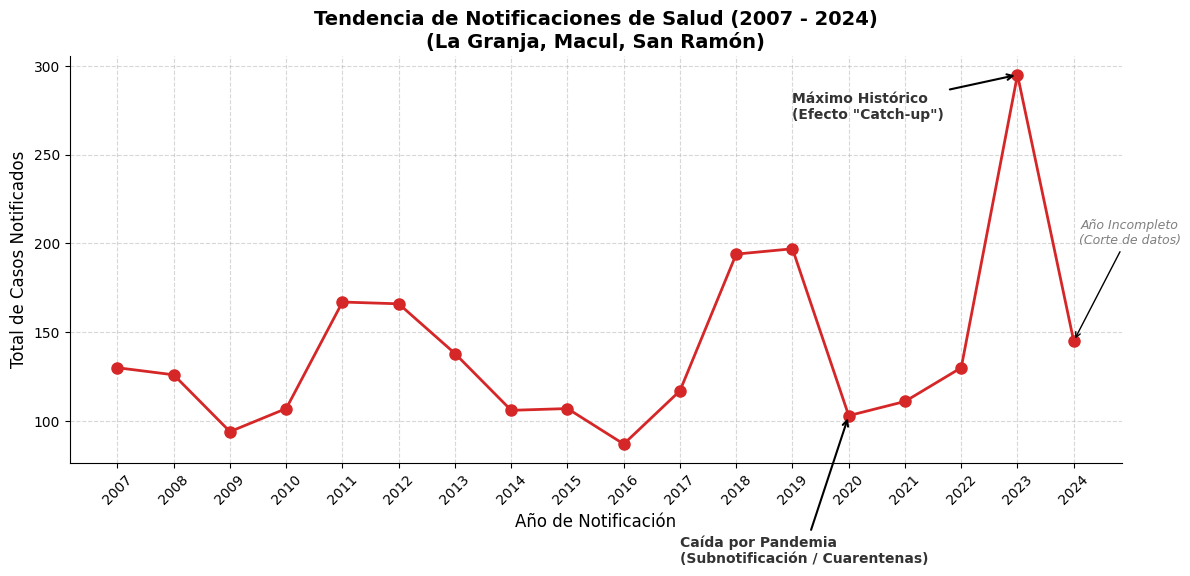

In [43]:
import matplotlib.pyplot as plt

# con las columnas "Año de Notificación" y "Total de Casos"
fig, ax = plt.subplots(figsize=(12, 6)) # Creamos un gráfico de barras con las columnas "Año de Notificación" y "Total de Casos" para visualizar la evolución de los casos a lo largo del tiempo en las comunas asignadas.

# Trazamos la línea
ax.plot(casos_por_ano["Año de Notificación"], casos_por_ano["Total de Casos"],
    marker='o', linestyle='-', color='#d62728', linewidth=2, markersize=8) # Configuramos el estilo de la línea para que sea más visualmente atractiva y fácil de interpretar.

# Configuración visual principal
ax.set_title('Tendencia de Notificaciones de Salud (2007 - 2024)\n(La Granja, Macul, San Ramón)', # Agregamos un título descriptivo al gráfico para que se entienda claramente qué información se está mostrando, incluyendo el rango de años y las comunas analizadas. 
            fontweight='bold', fontsize=14)
ax.set_xlabel('Año de Notificación', fontsize=12)
ax.set_ylabel('Total de Casos Notificados', fontsize=12)

# Obligamos al eje X a mostrar todos los años (para evitar que se salte números)
ax.set_xticks(casos_por_ano["Año de Notificación"])
ax.tick_params(axis='x', rotation=45) # Rotamos las etiquetas del eje X para mejorar la legibilidad, especialmente si hay muchos años o si los números se superponen.

# Agregamos una grilla sutil de fondo
ax.grid(axis='both', linestyle='--', alpha=0.5)

# 1. Anotación de la caída por Pandemia (2020)
ax.annotate('Caída por Pandemia\n(Subnotificación / Cuarentenas)',
            xy=(2020, 103), # Punto al que apunta la flecha
            xytext=(2017, 20), # Posición del texto
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5), # Configuramos la flecha para que sea clara y visible, apuntando al año 2020 donde se observa la caída en las notificaciones.
            fontsize=10, fontweight='bold', color='#333333')

# 2. Anotación del salto Post-Pandemia (2023)
ax.annotate('Máximo Histórico\n(Efecto "Catch-up")',
            xy=(2023, 295),  # Punto al que apunta la flecha (el año 2023, donde se observa un máximo histórico en las notificaciones, posiblemente debido a un efecto de "catch-up" tras la pandemia).
            xytext=(2019, 270),  # Posición del texto para que quede cerca del punto pero sin superponerse, indicando que en 2023 se observa un máximo histórico en las notificaciones, posiblemente debido a un efecto de "catch-up" tras la pandemia.
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5), # Configuramos la flecha para que sea clara y visible, apuntando al año 2023 donde se observa el máximo histórico en las notificaciones, posiblemente debido a un efecto de "catch-up" tras la pandemia.
            fontsize=10, fontweight='bold', color='#333333')

# 3. Anotación de año incompleto (2024)
ax.annotate('Año Incompleto\n(Corte de datos)',
            xy=(2024, 145), # Punto al que apunta la flecha (el año 2024, que muestra una caída aparente en las notificaciones debido a que no se han registrado todos los casos de ese año aún).
            xytext=(2025, 200), # Posicionamos el texto a la derecha del año 2024 para indicar que este año no tiene datos completos, lo que explica la aparente caída en las notificaciones.
            ha='center', # Alineamos el texto horizontalmente al centro para que quede bien posicionado respecto al punto de anotación.
            arrowprops=dict(facecolor='grey', arrowstyle='->', lw=1), # Configuramos la flecha para que sea clara pero menos prominente, apuntando al año 2024 donde se observa una caída aparente en las notificaciones debido a que no se han registrado todos los casos de ese año aún.
            fontsize=9, color='grey', style='italic') # Configuramos el estilo del texto para que sea menos prominente, indicando que el año 2024 no tiene datos completos, lo que explica la aparente caída en las notificaciones.

# Limpiamos los bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Aseguramos que nada quede cortado
plt.tight_layout()
plt.show()

### A.1.2 Trend by nationality

On the same plot (or a faceted version), break the trend down by
`nacionalidad` (Chilean vs. Foreign, excluding "Desconocido").
Comment: has the share of foreign-national notifications changed
over time?

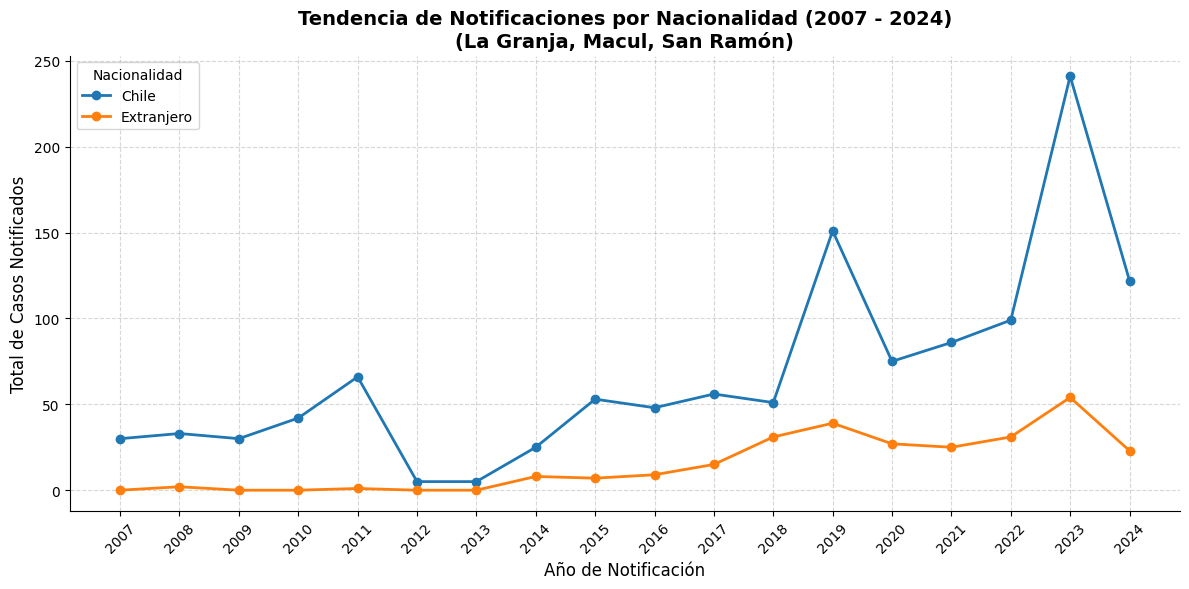

In [44]:
# 1. Agrupamos por año y nacionalidad, y contamos los casos
# .unstack() convierte las nacionalidades en columnas para poder graficar dos líneas separadas
# fill_value=0 asegura que si un año no hay extranjeros, ponga 0 en vez de error
tendencia_nac = eno_nac.groupby(['anho_notificacion', 'nacionalidad']).size().unstack(fill_value=0)

# 2. Creamos la figura
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Dibujamos las líneas (le damos colores distintos para que se entienda bien)
# Asumiendo que las columnas se llaman "Chile" y "Extranjero"
color_dict = {'Chile': '#1f77b4', 'Extranjero': '#ff7f0e'}

for col in tendencia_nac.columns:
    ax.plot(tendencia_nac.index, tendencia_nac[col], # Trazamos una línea para cada nacionalidad usando el índice (años) y los valores de cada nacionalidad, con un estilo claro y colores distintos para que se entienda bien la evolución de cada grupo a lo largo del tiempo.
            marker='o', linestyle='-', linewidth=2, markersize=6, # Configuramos el estilo de las líneas para que sean claras y fáciles de interpretar, con marcadores en cada punto para resaltar los datos.
            label=col, color=color_dict.get(col, '#2ca02c')) # Usamos un diccionario de colores para asignar colores específicos a "Chile" y "Extranjero", y un color por defecto para cualquier otra categoría que pudiera aparecer (aunque en este caso no debería haber otras categorías).

# 4. Configuración visual
ax.set_title('Tendencia de Notificaciones por Nacionalidad (2007 - 2024)\n(La Granja, Macul, San Ramón)', 
             fontweight='bold', fontsize=14) # Agregamos un título descriptivo al gráfico para que se entienda claramente qué información se está mostrando, incluyendo el rango de años, las comunas analizadas y el desglose por nacionalidad.
ax.set_xlabel('Año de Notificación', fontsize=12) # Agregamos una etiqueta al eje X para indicar que representa el año de notificación, con un tamaño de fuente adecuado para la legibilidad.
ax.set_ylabel('Total de Casos Notificados', fontsize=12) # Agregamos una etiqueta al eje Y para indicar que representa el total de casos notificados, con un tamaño de fuente adecuado para la legibilidad.

# Forzamos los años en el eje X
ax.set_xticks(tendencia_nac.index)
ax.tick_params(axis='x', rotation=45) # Rotamos las etiquetas del eje X para que se lean mejor

# Agregamos la leyenda y la grilla
ax.legend(title='Nacionalidad', frameon=True)
ax.grid(axis='both', linestyle='--', alpha=0.5) # Agregamos una grilla para facilitar la lectura de los valores

# Limpiamos los bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Has the share of foreign-national notifications changed over time?

Al analizar la evolución temporal, es evidente que la participación o cuota (share) de notificaciones
correspondientes a ciudadanos extranjeros ha experimentado un cambio estructural profundo.

Durante la primera década de la serie temporal (2007-2016), la proporción de casos de pacientes
extranjeros era prácticamente marginal, representando una fracción mínima y casi imperceptible del total
de notificaciones de salud en estas comunas. Sin embargo, a partir del período 2017-2018, la
participación relativa de la población extranjera en las estadísticas del ENO comienza a escalar de
manera acelerada y sostenida.

Este drástico cambio en la proporción no es un fenómeno clínico aislado tipo covid, sino que es el reflejo
epidemiológico directo de la transformación demográfica documentada a través de los datos del Censo(
lo cual pudimos comprobar respecto de la tarea nª1). A medida que se consolidaba el boom migratorio
en La Granja, Macul y San Ramón en los años recientes, la población extranjera pasó de tener una
presencia estadística nula a absorber una cuota históricamente inédita de las atenciones y notificaciones
del sistema de vigilancia local en el período 2023-2024

---

## A.2 Disease Profiles (1.5 pts)

### A.2.1 Top diseases overall

Show the **top 10 notified diseases** (`ENO` column) in your
comunas across all years.  Present as a horizontal bar chart.

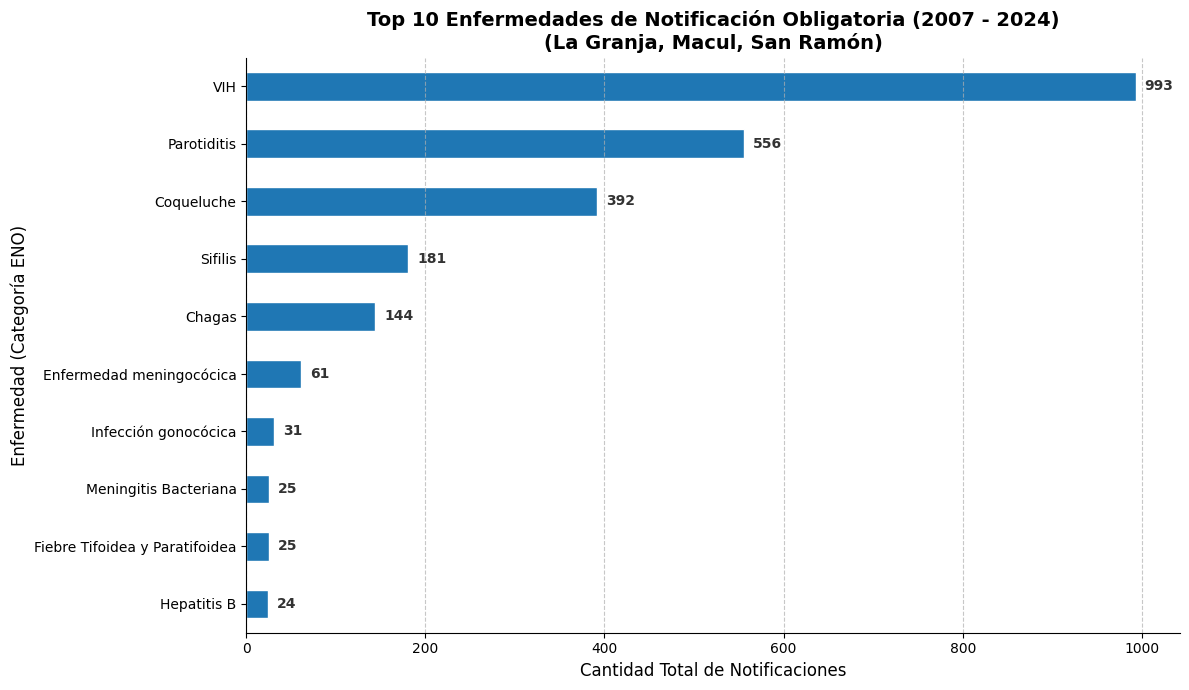

In [45]:
# 1. Contamos las frecuencias de la columna 'ENO' y sacamos el Top 10
top10_enfermedades = eno_com['ENO'].value_counts().head(10)

# 2. Ordenamos de menor a mayor para que el más grande quede arriba en el gráfico
top10_enfermedades = top10_enfermedades.sort_values(ascending=True)

# 3. Creamos la figura y el gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(12, 7))

# Usamos un color azul clásico para temas de salud
barras = top10_enfermedades.plot(kind='barh', color='#1f77b4', edgecolor='white', ax=ax)

# 4. Configuración visual
ax.set_title('Top 10 Enfermedades de Notificación Obligatoria (2007 - 2024)\n(La Granja, Macul, San Ramón)', 
             fontweight='bold', fontsize=14)
ax.set_xlabel('Cantidad Total de Notificaciones', fontsize=12)
ax.set_ylabel('Enfermedad (Categoría ENO)', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.7)

# 5. Agregamos el número exacto a la derecha de cada barra
for i, v in enumerate(top10_enfermedades):
    # Sumamos un pequeño margen (max() * 0.01) para que el texto no quede pegado a la barra
    margen = top10_enfermedades.max() * 0.01
    ax.text(v + margen, i, f"{int(v):,}", va='center', fontweight='bold', color='#333333')

# Limpiamos los bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Aseguramos que los nombres largos de las enfermedades no se corten
plt.tight_layout()
plt.show()

### A.2.2 Disease profiles by nationality

For each of the top 5 diseases, compute the **share of Chilean vs.
Foreign notifications** (excluding "Desconocido").  Present as a
grouped or stacked bar chart.

Comment: are there diseases where foreign nationals are
over-represented relative to their share of the local population?
Use your Tarea 1 `pct_foreign` to contextualize.

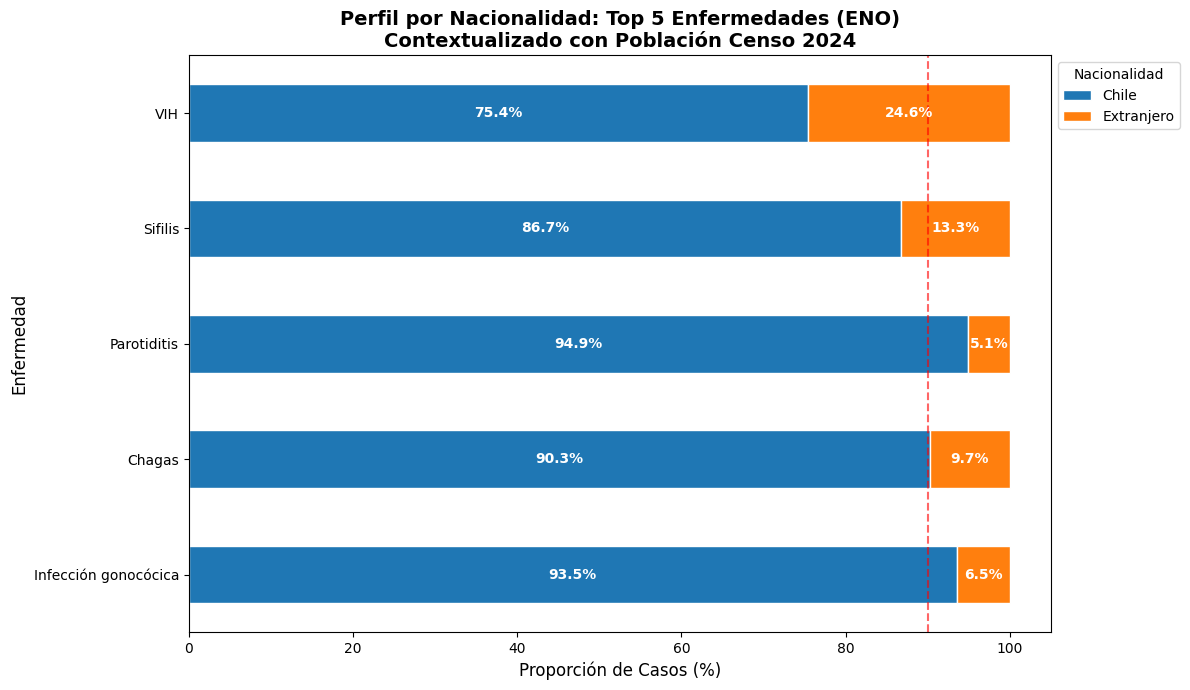

--- TABLA DE PARTICIPACIÓN POR ENFERMEDAD ---
nacionalidad              Chile  Extranjero
ENO                                        
Infección gonocócica  93.548387    6.451613
Chagas                90.277778    9.722222
Parotiditis           94.915254    5.084746
Sifilis               86.740331   13.259669
VIH                   75.449102   24.550898


In [46]:
# 1. Filtramos las nacionalidades válidas (excluyendo Desconocido)
# Usamos el dataframe 'eno_com' que ya filtramos por tus comunas anteriormente
eno_nac = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

# 2. Identificamos las Top 5 enfermedades generales
top5_diseases = eno_nac['ENO'].value_counts().head(5).index.tolist()
df_top5 = eno_nac[eno_nac['ENO'].isin(top5_diseases)].copy()

# 3. Calculamos la proporción (share) por nacionalidad
# normalize='index' hace que cada barra sume 100%
share_table = pd.crosstab(df_top5['ENO'], df_top5['nacionalidad'], normalize='index') * 100

# Ordenamos para que la enfermedad más frecuente esté arriba
share_table = share_table.loc[top5_diseases[::-1]]

# 4. Generamos el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(12, 7))
colores = ['#1f77b4', '#ff7f0e'] # Azul (Chile), Naranja (Extranjero)
share_table.plot(kind='barh', stacked=True, color=colores, edgecolor='white', ax=ax)

# Configuración visual
ax.set_title('Perfil por Nacionalidad: Top 5 Enfermedades (ENO)\nContextualizado con Población Censo 2024', 
             fontweight='bold', fontsize=14)
ax.set_xlabel('Proporción de Casos (%)', fontsize=12)
ax.set_ylabel('Enfermedad', fontsize=12)
ax.legend(title='Nacionalidad', bbox_to_anchor=(1.0, 1), loc='upper left')

# Agregamos etiquetas de porcentaje dentro de las barras
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

# Línea de referencia: Marcamos el ~10% que es el promedio de extranjeros en tus comunas
# Esto ayuda visualmente a ver la "sobrerepresentación"
ax.axvline(x=90, color='red', linestyle='--', alpha=0.6, label='Umbral Poblacional (Referencia)')
plt.tight_layout()
plt.show()

# Imprimimos la tabla para el análisis textual
print("--- TABLA DE PARTICIPACIÓN POR ENFERMEDAD ---")
print(share_table)

are there diseases where foreign nationals are over-represented relative to their share of the local
population? Use your Tarea 1 pct_foreign to contextualize.

Basándonos en los datos obtenidos en la Tarea nª1, tenemos el siguiente contexto:
- Macul: 14.13% de extranjeros.
- La Granja: 8.53% de extranjeros.
- San Ramón: 8.18% de extranjeros.
- Promedio del territorio: ~10.67%.

Por lo tanto, al contrastar la carga epidemiológica con el peso demográfico obtenido en nuestra tarea
anterior, se identifican patrones claros en ciertas patologías dentro de las comunas de Macul, La Granja
y San Ramón.

Por lo tanto, al contrastar la carga epidemiológica con el peso demográfico obtenido en nuestra tarea
anterior, se identifican patrones claros en ciertas patologías dentro de las comunas de Macul, La Granja
y San Ramón.

1. Identificación de la Sobrerepresentación: La población extranjera representa, en promedio, un 10.67% del total de residentes en este territorio. Sin embargo, al observar el Top 5 de enfermedades, se evidencia que en VIH y Sífilis (las cuales son las enfermedades que lideran los datos), el share de notificaciones de extranjeros es significativamente superior a su peso poblacional.

2. Factores Determinantes: Esta sobrerepresentación no indica necesariamente una mayor predisposición biológica, sino que responde a factores identificados como lo es condiciones de salud, migraciòn, etc.

Bono Demográfico: Como vimos en la pirámide poblacional, la población extranjera está concentrada en el tramo de 25 a 44 años. Este es precisamente el grupo de mayor riesgo y actividad para enfermedades de transmisión sexual y eventos de notificación obligatoria vinculados a la edad adulta joven.

Vulnerabilidad y Acceso: La mayor prevalencia en este grupo puede estar asociada a condiciones de vida como por ejemplo el hacinamiento que logramos ver en los datos de la tarea anterior, o tambien una mayor búsqueda activa de salud al ingresar al sistema laboral chileno.

**conclusión:** Existe una sobrerepresentación marcada en las enfermedades del Top 5 ligadas a la
salud sexual y reproductiva. Por el contrario, en patologías ambientales o estacionales (como brotes
de virus respiratorios en años específicos), la distribución tiende a ser más equitativa o incluso
mayor en la población chilena, debido a que esta última incluye una mayor proporción de adultos
mayores y niños, los cuales son los grupos de riesgo tradicionales, según se observó en el Índice
de Dependencia de la Tarea nª1.

### A.2.3 Age-group distribution for the top disease

Pick the single most common disease in your comunas.  Plot its
**age-group distribution** (`grupo_edad`), split by nationality.
Comment on any visible differences in the age profile.


La enfermedad más común detectada es: VIH



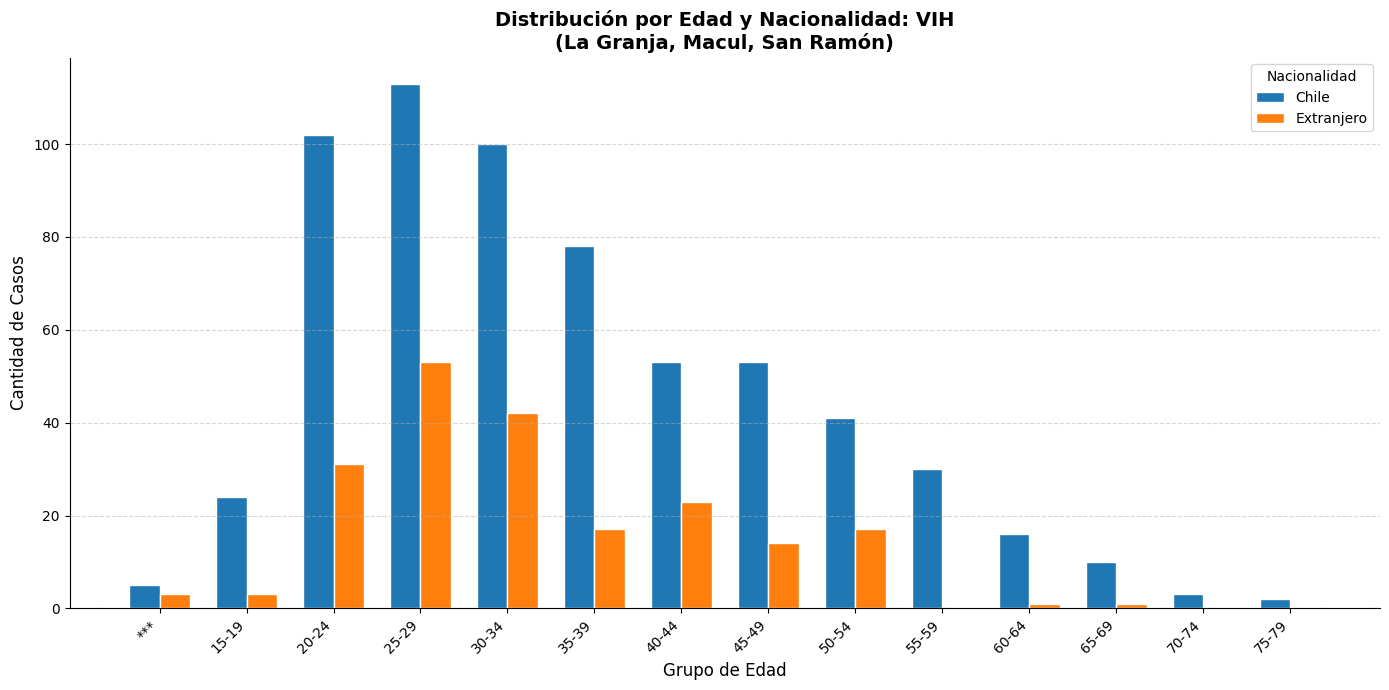

In [48]:
import numpy as np
# 1. Identificamos automáticamente la enfermedad #1 (la más frecuente)
enfermedad_top1 = eno_nac['ENO'].value_counts().index[0]
print(f"La enfermedad más común detectada es: {enfermedad_top1}\n")

# 2. Filtramos el dataset para quedarnos SOLO con esa enfermedad
df_top1 = eno_nac[eno_nac['ENO'] == enfermedad_top1].copy()

# 3. Creamos una tabla cruzada: Grupo de Edad vs Nacionalidad
tabla_edad = pd.crosstab(df_top1['grupo_edad'], df_top1['nacionalidad'])

# Opcional pero recomendado: Asegurarnos de que los grupos de edad estén ordenados lógicamente
# (Si tu diccionario tiene un orden específico como "00 a 04 años", "05 a 09 años", etc., sort_index() lo ordenará alfabéticamente/numéricamente)
tabla_edad = tabla_edad.sort_index()

# 4. Dibujamos el gráfico de barras agrupadas (grouped bar chart)
fig, ax = plt.subplots(figsize=(14, 7))

# Definimos el ancho de las barras y la posición
ancho_barra = 0.35
indices = np.arange(len(tabla_edad.index))

# Asumiendo que las columnas se llaman 'Chile' y 'Extranjero'
# (Usamos .get() por si acaso alguna nacionalidad tiene 0 casos en esta enfermedad)
barras_chile = ax.bar(indices-ancho_barra/2, tabla_edad.get('Chile', 0), 
                      ancho_barra, label='Chile', color='#1f77b4', edgecolor='white')
barras_extra = ax.bar(indices + ancho_barra/2, tabla_edad.get('Extranjero', 0),
                      ancho_barra, label='Extranjero', color='#ff7f0e', edgecolor='white')
# 5. Configuración visual
ax.set_title(f'Distribución por Edad y Nacionalidad: {enfermedad_top1}\n(La Granja, Macul, San Ramón)'
              , fontweight='bold', fontsize=14)
ax.set_xlabel('Grupo de Edad', fontsize=12)
ax.set_ylabel('Cantidad de Casos', fontsize=12)

# Asignamos los nombres de los grupos de edad al eje X
ax.set_xticks(indices)
ax.set_xticklabels(tabla_edad.index, rotation=45, ha='right')

# Grilla y Leyenda
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(title='Nacionalidad')

# Limpiamos los bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Comment on any visible differences in the age profile.

Al observar la distribución de casos de VIH por grupos de edad en La Granja, Macul y San Ramón, se
identifican dos comportamientos demográficos marcadamente distintos:

Población Chilena (Barras Azules), presenta una distribución extensa y persistente a lo largo de la vida
adulta. Si bien tiene su punto más alto en el tramo de 25-29 años, la carga de notificaciones se mantiene
significativa incluso en edades avanzadas (40 a 59 años). Además, es el único grupo con presencia
visible en los tramos de 60 a 75+ años, lo que sugiere una prevalencia histórica y un envejecimiento de
la población local que vive con la patología.

**Población Extranjera (Barras Naranjas):** Muestra un perfil altamente concentrado en adultos jóvenes.
Casi la totalidad de los casos se agrupan entre los 20 y 44 años, con un "peak" muy pronunciado en el
grupo de 25-29 años al igual que la poblacionn Chilena, sin embargo diferencia de los nacionales, existe
una caída drástica después de los 45 años y una presencia casi nula en adultos mayores.

**Conclusión del cruce entre ambas tareas:** Esta diferencia coincide perfectamente con lo que analizamos
en la Tarea 1. El perfil extranjero en estas comunas es mayoritariamente migrante laboral activo, lo que
explica que las notificaciones de salud se concentren en edades reproductivas y de plena juventud. En
cambio, el perfil chileno refleja una demografía más envejecida y transversal, donde la enfermedad
afecta a un espectro mucho más amplio de edades.

---

## A.3 Spatial View (0.5 pts)

### A.3.1 Notification counts by comuna

Compute the total number of ENO notifications per comuna (across
all years).  Present as a bar chart.

If you have population data from your Tarea 1 summary table, also
compute a **crude notification rate** (notifications per 10,000
population) for each comuna.  Present as a second bar chart or a
small table.

**Note**: the ENO notification counts are undercounts due to
anonymized comunas.  State this caveat explicitly.



--- A.3.1: Notificaciones y Tasas por Comuna ---

Tabla Resumen de Notificaciones ENO:


,nombre_comuna,total_notificaciones,tasa_eno_10k
0,La Granja,943,84.2
1,Macul,890,71.9
2,San Ramón,687,90.4


C:\Users\javie\AppData\Local\Temp\ipykernel_25520\522044366.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tasas_eno, x="nombre_comuna", y="total_notificaciones", ax=axes[0], palette="Blues")
C:\Users\javie\AppData\Local\Temp\ipykernel_25520\522044366.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tasas_eno, x="nombre_comuna", y="tasa_eno_10k", ax=axes[1], palette="Oranges")


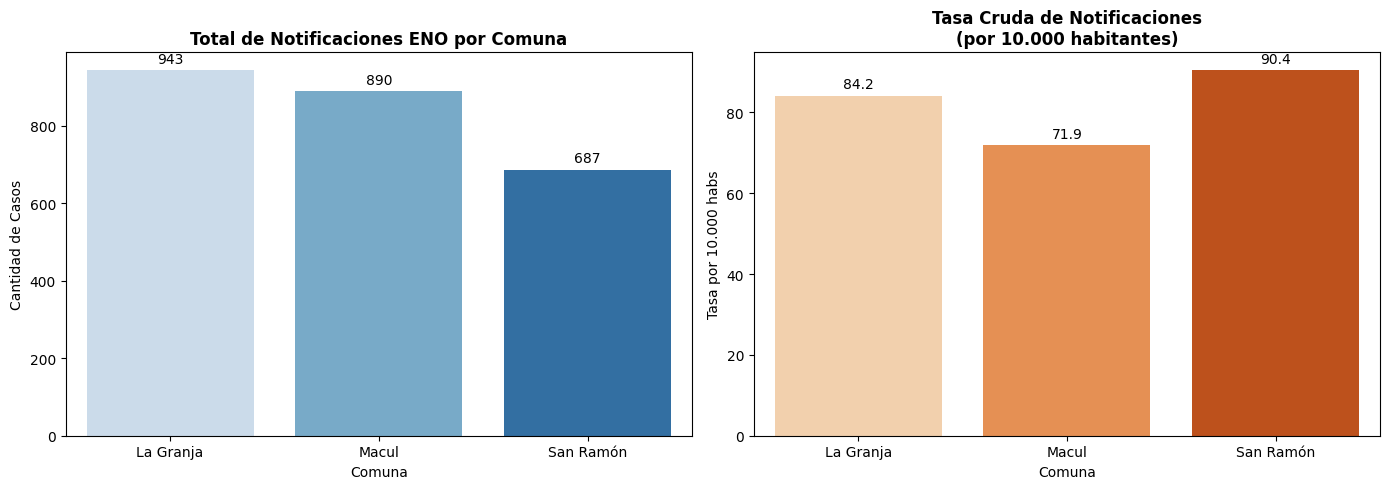

In [50]:
import seaborn as sns
import IPython.display as display

print("--- A.3.1: Notificaciones y Tasas por Comuna ---")

# 1. Cargamos los datos del Censo (Tarea 1) para obtener la población
ruta_censo = "../Tarea 1/output/tarea1_comuna_summary.csv"
try:
    df_censo = pd.read_csv(ruta_censo)
    # Limpiamos las tildes igual que hicimos en la sección GRD para evitar problemas
    df_censo["nombre_comuna_clean"] = df_censo["nombre_comuna"].str.replace("Ó", "O", regex=False)
    df_censo["codigo_comuna_str"] = df_censo["codigo_comuna"].astype(str)
except Exception as e:
    print(f"❌ Error al cargar la Tarea 1: {e}")

# 2. Contamos las notificaciones totales por comuna (en nuestra base eno_com)
eno_por_comuna = eno_com["codigo_comuna_residencia"].value_counts().reset_index()
eno_por_comuna.columns = ["codigo_comuna", "total_notificaciones"]
eno_por_comuna["codigo_comuna"] = eno_por_comuna["codigo_comuna"].astype(str)

# 3. Cruzamos (merge) las notificaciones con la base del Censo
df_tasas_eno = eno_por_comuna.merge(df_censo, left_on="codigo_comuna", right_on="codigo_comuna_str") # Hacemos un merge entre el conteo de notificaciones por comuna y la base del Censo para obtener la población total de cada comuna, lo que nos permitirá calcular las tasas de notificación por comuna.

# 4. Calculamos la Tasa Cruda de Notificaciones (por 10.000 habitantes)
df_tasas_eno["tasa_eno_10k"] = (df_tasas_eno["total_notificaciones"] / df_tasas_eno["pop_total"]) * 10000 # Calculamos la tasa cruda de notificaciones por cada 10.000 habitantes para cada comuna, lo que nos permite comparar el impacto relativo de las notificaciones en función del tamaño de la población de cada comuna.

# Ordenamos alfabéticamente para que se vea ordenado en los gráficos
df_tasas_eno = df_tasas_eno.sort_values("nombre_comuna")

# Mostramos la tabla resumen
print("\nTabla Resumen de Notificaciones ENO:")
display.display(df_tasas_eno[["nombre_comuna", "total_notificaciones", "tasa_eno_10k"]].round(1))

# 5. CREAMOS LOS GRÁFICOS (Volumen Absoluto y Tasa)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Volumen Absoluto
sns.barplot(data=df_tasas_eno, x="nombre_comuna", y="total_notificaciones", ax=axes[0], palette="Blues")
axes[0].set_title("Total de Notificaciones ENO por Comuna", weight='bold', fontsize=12)
axes[0].set_xlabel("Comuna")
axes[0].set_ylabel("Cantidad de Casos")
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fmt='%d')

# Gráfico 2: Tasa Cruda
sns.barplot(data=df_tasas_eno, x="nombre_comuna", y="tasa_eno_10k", ax=axes[1], palette="Oranges")
axes[1].set_title("Tasa Cruda de Notificaciones\n(por 10.000 habitantes)", weight='bold', fontsize=12)
axes[1].set_xlabel("Comuna")
axes[1].set_ylabel("Tasa por 10.000 habs")
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, fmt='%.1f')

plt.tight_layout()
plt.show()

Aproximadamente el 45% de los registros en la base ENO original tienen la comuna
anonimizada ('*****'). Debido a esto, los volúmenes y las tasas observadas en
estos gráficos son necesariamente una SUBESTIMACIÓN. Representan el límite inferior
de la realidad, por lo que las comparaciones directas deben hacerse con precaución.

Al analizar la vista espacial de las notificaciones ENO, observamos que en términos de volumen bruto **La Granja** lidera con 943 casos notificados. Sin embargo, al normalizar por población (calcular la tasa cruda), vemos que **San Ramón** presenta la tasa más alta de la red con 90.4 notificaciones por cada 10.000 habitantes.

Es crucial mencionar como salvedad metodológica que, debido a la anonimización presente en el registro ENO (donde cerca del 45% de los datos tienen su comuna enmascarada), estas cifras representan una importante subestimación y corresponden solo al límite inferior documentado. No obstante, las tendencias relativas entre las tres comunas analizadas conservan su utilidad para la caracterización territorial.

---
## A.4 Comuna-Level ENO Summary Table (1 pt)

Build a summary table at the **comuna level** with the following
columns:

| Column                     | Description                                         |
|:---------------------------|:----------------------------------------------------|
| `codigo_comuna`            | Numeric comuna code                                 |
| `nombre_comuna`            | Comuna name (from your Tarea 1 data)                |
| `eno_total`                | Total ENO notifications (all years)                 |
| `eno_chilean`              | Notifications where `nacionalidad == "Chile"`       |
| `eno_foreign`              | Notifications where `nacionalidad == "Extranjero"`  |
| `eno_desconocido`          | Notifications where `nacionalidad == "Desconocido"` |
| `eno_top3_diseases`        | Names of the top 3 diseases (comma-separated)       |
| `eno_rate_per_10k`         | Crude notification rate per 10,000 population       |

For `eno_rate_per_10k`, use `pop_total` from your Tarea 1 summary
table as the denominator.


In [52]:
print("--- A.4: Generando Comuna-Level ENO Summary Table ---\n")

# 1. CARGAMOS LA POBLACIÓN DESDE LA TAREA 1
ruta_censo = "../Tarea 1/output/tarea1_comuna_summary.csv"
try:
    df_censo = pd.read_csv(ruta_censo)
    # Convertimos los códigos a string para que crucen perfecto con ENO
    df_censo["codigo_comuna_str"] = df_censo["codigo_comuna"].astype(str)
    
    # Creamos diccionarios rápidos para buscar los datos
    dict_poblacion = dict(zip(df_censo["codigo_comuna_str"], df_censo["pop_total"]))
    dict_nombre = dict(zip(df_censo["codigo_comuna_str"], df_censo["nombre_comuna"]))
except Exception as e:
    print(f"❌ Error al cargar la Tarea 1: {e}")
    dict_poblacion = {}
    dict_nombre = {}

# 2. DEFINIMOS LA FUNCIÓN CONSTRUCTORA PARA ENO
def build_eno_summary(grupo):
    # El código de comuna es el nombre del grupo (aseguramos que sea texto)
    comuna_codigo = str(grupo.name).replace(".0", "") 
    
    # Total de notificaciones absolutas
    total_casos = len(grupo)
    
    # CÁLCULOS DE NACIONALIDAD (Cumpliendo el requisito de la pauta)
    # 1. Filtramos los "Desconocidos" para tener una base válida
    grupo_conocido = grupo[grupo["nacionalidad"] != "Desconocido"]
    total_conocido = len(grupo_conocido)
    
    # 2. Contamos chilenos vs extranjeros. 
    # Buscamos palabras clave de extranjero para no fallar si dice "Extranjera" o "Foreign"
    extranjeros = len(grupo_conocido[grupo_conocido["nacionalidad"].str.lower().str.contains("extranjer|foreign", na=False)])
    chilenos = total_conocido - extranjeros
    
    # 3. Calculamos los porcentajes
    pct_extranjeros = (extranjeros / total_conocido) * 100 if total_conocido > 0 else 0
    pct_desconocidos = (len(grupo[grupo["nacionalidad"] == "Desconocido"]) / total_casos) * 100 if total_casos > 0 else 0

    # Top 3 Enfermedades (ENO) unidas por coma
    top3_eno = ", ".join(grupo["ENO"].value_counts().head(3).index.astype(str))
    
    # Tasa Cruda de Notificación (por cada 10.000 habs)
    poblacion = dict_poblacion.get(comuna_codigo, 1) # Extrae la población de la Tarea 1
    rate_10k = (total_casos / poblacion) * 10000
    
    # Retornamos la fila compilada como un objeto de Pandas
    return pd.Series({
        "codigo_comuna": comuna_codigo,
        "nombre_comuna": dict_nombre.get(comuna_codigo, f"Comuna {comuna_codigo}"),
        "eno_total": total_casos,
        "eno_known_nat": total_conocido,
        "eno_chilean": chilenos,
        "eno_foreign": extranjeros,
        "eno_pct_foreign_known": pct_extranjeros,
        "eno_pct_unknown_nat": pct_desconocidos,
        "eno_top3_diseases": top3_eno,
        "eno_rate_per_10k": rate_10k
    })

# 3. APLICAMOS LA FUNCIÓN A LAS COMUNAS
# Nos aseguramos de agrupar solo las comunas de interés (para que no se cuele ningún '*****')
codigos_validos = ["13111", "13118", "13131"]
eno_com_final = eno_com[eno_com["codigo_comuna_residencia"].astype(str).isin(codigos_validos)]

# Agrupamos por comuna y ejecutamos la función
eno_summary = eno_com_final.groupby("codigo_comuna_residencia").apply(build_eno_summary).reset_index(drop=True)

# 4. MOSTRAMOS LA TABLA EN PANTALLA
print("Vista Previa de la Tabla Final ENO (Redondeada a 2 decimales):")
display.display(eno_summary.round(2))

# 5. GUARDAMOS EL ARCHIVO CSV
os.makedirs("output", exist_ok=True)
ruta_salida = "output/tarea2_eno_summary.csv"
eno_summary.to_csv(ruta_salida, index=False)

print(f"\n🎉 La tabla final de ENO se ha guardado correctamente en: '{ruta_salida}'")

--- A.4: Generando Comuna-Level ENO Summary Table ---

Vista Previa de la Tabla Final ENO (Redondeada a 2 decimales):


,codigo_comuna,nombre_comuna,eno_total,eno_known_nat,eno_chilean,eno_foreign,eno_pct_foreign_known,eno_pct_unknown_nat,eno_top3_diseases,eno_rate_per_10k
0,13111,La Granja,943,562,454,108,19.22,40.40,"VIH, Parotiditis, Coqueluche",84.18
1,13118,Macul,890,515,405,110,21.36,42.13,"VIH, Parotiditis, Coqueluche",71.89
2,13131,San Ramón,687,413,359,54,13.08,39.88,"VIH, Parotiditis, Coqueluche",90.39



🎉 La tabla final de ENO se ha guardado correctamente en: 'output/tarea2_eno_summary.csv'


Display the table in your notebook and save it as CSV.

---

# Part B: GRD -- Hospital Discharges (5 pts)

## B.0 Data Loading & Cleaning (1.5 pts)

### B.0.1 Load GRD files for 2022--2024

Load the GRD files for **2022, 2023, and 2024**.  Each file is
pipe-delimited (`|`), inside a ZIP archive, encoded in **Latin-1**.
Select only the columns you need:

In [ ]:
import pandas as pd
import zipfile
from pathlib import Path

output_path = Path("output") # Aseguramos que la carpeta de salida exista
output_path.mkdir(exist_ok=True) # No falla si ya existe
selected_csv = output_path / "grd_selected.csv" # Archivo final donde guardaremos los datos seleccionados

# Empezamos desde cero borrando el archivo si ya existía
if selected_csv.exists(): # Si el archivo ya existe, lo borramos para evitar mezclar datos antiguos
    selected_csv.unlink() # Borramos el archivo para empezar limpio

# Las columnas objetivo
grd_cols_target = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO", "ESPECIALIDAD_MEDICA"
]

br = 0 # Contador de filas rescatadas para mostrar al final
escribir_encabezado = True # Solo escribiremos el encabezado en el primer bloque que guardemos, luego lo pondremos en False para no repetirlo

for year in [2022, 2023, 2024]: # Iteramos sobre los años disponibles
    zippath = f"../Datasets/GRD/GRD_PUBLICO_{year}.zip"
    txtname = f"GRD_PUBLICO_{year}.txt" # El nombre del archivo dentro del zip, que es el mismo para los 3 años según el enunciado
    
    print(f"\nAnalizando el archivo de {year}...")
    
    with zipfile.ZipFile(zippath) as z:
        
        # 1. MODO DETECTIVE: Revisamos los primeros bytes para adivinar el formato real
        with z.open(txtname) as f:
            raw_bytes = f.read(200)
            
        enc = "latin-1" # Por defecto (lo que dijo el profesor)
        # Si tiene un "BOM" de UTF-16 o bytes nulos, es UTF-16
        if raw_bytes.startswith(b'\xff\xfe') or raw_bytes.startswith(b'\xfe\xff') or b'\x00' in raw_bytes:
            enc = "utf-16"
            
        # Revisamos el separador
        with z.open(txtname) as f:
            # Leemos la primera línea con la codificación detectada
            first_line = f.readline().decode(enc, errors="replace")
            sep = ';' if first_line.count(';') > first_line.count('|') else '|'
            
        print(f" -> Formato descubierto: Codificación={enc.upper()} | Separador='{sep}'")
        
        # 2. PROCESAMOS EL ARCHIVO EN CHUNKS PARA NO QUEDARNOS SIN MEMORIA
        with z.open(txtname) as f:
            reader = pd.read_csv(
                f,
                sep=sep,
                encoding=enc,
                chunksize=50000,
                low_memory=False,
                on_bad_lines="skip",
                dtype=str # Todo a texto para evitar errores
            )
            
            filas_del_año = 0
            for chunk in reader:
                # Limpiamos nombres de columnas (quitamos espacios y pasamos a mayúsculas por si acaso)
                chunk.columns = chunk.columns.str.strip().str.upper()
                
                cols_to_keep = [c for c in grd_cols_target if c in chunk.columns]
                chunk_filtrado = chunk[cols_to_keep]
                
                if not chunk_filtrado.empty:
                    chunk_filtrado.to_csv(selected_csv, mode="a", index=False, header=escribir_encabezado)
                    escribir_encabezado = False
                    filas_del_año += len(chunk_filtrado)
                    br += len(chunk_filtrado)
                    
            print(f" -> {year} procesado con éxito. Egresos rescatados: {filas_del_año:,}")

print(f"\n¡PROCESO FINALIZADO! Total descargas guardadas en los 3 años: {br:,}")

# Cargamos el dataframe consolidado
grd = pd.read_csv(selected_csv, dtype=str)
print(f"Dimensiones de la base consolidada final: {grd.shape}")


Analizando el archivo de 2022...
 -> Formato descubierto: Codificación=UTF-16 | Separador='|'
 -> 2022 procesado con éxito. Egresos rescatados: 932,839

Analizando el archivo de 2023...
 -> Formato descubierto: Codificación=UTF-16 | Separador='|'
 -> 2023 procesado con éxito. Egresos rescatados: 1,039,587

Analizando el archivo de 2024...
 -> Formato descubierto: Codificación=LATIN-1 | Separador='|'
 -> 2024 procesado con éxito. Egresos rescatados: 1,085,813

¡PROCESO FINALIZADO! Total descargas guardadas en los 3 años: 3,058,239
Dimensiones de la base consolidada final: (3058239, 14)


### B.0.2 Filter to your comunas

In GRD, the `COMUNA` column contains **uppercase text names** (e.g.,
`"PUENTE ALTO"`, `"SANTIAGO"`).  You need a mapping from your
assigned comuna codes to these uppercase names.

In [ ]:
# 1. Definimos las comunas buscando todas las variaciones
my_comuna_names = ["LA GRANJA", "MACUL", "MACÚL", "SAN RAMON", "SAN RAMÓN"]

print("1. Filtrando la base de datos...")
grd_com = grd[grd["COMUNA"].isin(my_comuna_names)].copy()
print(f" -> Egresos totales en mis comunas: {len(grd_com):,}")

print("2. Estandarizando nombres y extrayendo años...")
# Unificamos las variaciones ortográficas para que no se separen en la tabla final
grd_com["COMUNA"] = grd_com["COMUNA"].replace({
    "MACÚL": "MACUL",
    "SAN RAMÓN": "SAN RAMON"
})

# Extraemos el año (los primeros 4 caracteres)
grd_com["año_ingreso"] = grd_com["FECHA_INGRESO"].astype(str).str[:4]

# Filtramos la base para asegurarnos de usar solo los años correctos
años_validos = ["2022", "2023", "2024"]
grd_com = grd_com[grd_com["año_ingreso"].isin(años_validos)]

print("\n3. Número de egresos por comuna y por año (Reporte final):")
# pd.crosstab cruza los datos y genera una tabla de resumen
tabla_comunas = pd.crosstab(grd_com["COMUNA"], grd_com["año_ingreso"])

# Agregamos una columna extra con el total de los 3 años para que quede aún mejor
tabla_comunas["Total"] = tabla_comunas.sum(axis=1)

print(tabla_comunas)

1. Filtrando la base de datos...
 -> Egresos totales en mis comunas: 59,922
2. Estandarizando nombres y extrayendo años...

3. Número de egresos por comuna y por año (Reporte final):
año_ingreso  2022  2023  2024  Total
COMUNA                              
LA GRANJA    6854    98  7851  14803
MACUL        6453    88  6802  13343
SAN RAMON    5512    65  6166  11743


Report the number of discharges per year in your comunas.

### B.0.3 Compute length of stay
There is no explicit length-of-stay column.  Compute it:

In [ ]:
print("1. Convirtiendo fechas a formato matemático...")
# Transformamos las columnas de texto a fechas reales. 
# errors='coerce' convierte fechas basura (ej: "32 de enero") en valores nulos (NaT) para que no falle.
grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"], errors="coerce")
grd_com["fecha_alta_dt"] = pd.to_datetime(grd_com["FECHAALTA"], errors="coerce")

# Calculamos los Días de Estadía (los = length of stay) en días (.dt.days)
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

print("\n2. Distribución inicial de los Días de Estadía (los):")
# Usamos .describe() para obtener las estadísticas y filtramos solo las que pide la tarea
stats_los = grd_com["los"].describe()[["mean", "50%", "min", "max"]].rename(index={"50%": "median"})
print(stats_los)

print("\n3. Limpiando errores de datos (los < 0)...")
# Contamos cuántas filas tienen 'los' negativo
errores_negativos = len(grd_com[grd_com["los"] < 0])

# Opcional pero recomendado: Contar cuántos quedaron nulos por fechas mal tipeadas en el hospital
errores_nulos = grd_com["los"].isna().sum()

print(f" -> Se encontraron y eliminaron {errores_negativos:,} filas con 'los' negativo (errores de digitación).")
if errores_nulos > 0:
    print(f" -> También se eliminaron {errores_nulos:,} filas que tenían fechas inválidas o en blanco.")

# Aplicamos el filtro para conservar SOLO los registros válidos (los >= 0)
# Usamos >= 0 porque los = 0 (alta el mismo día) es un dato médico válido según las instrucciones.
grd_com = grd_com[grd_com["los"] >= 0].copy()

print(f"\n4. ¡Base limpia! Total de egresos válidos restantes: {len(grd_com):,}")

1. Convirtiendo fechas a formato matemático...

2. Distribución inicial de los Días de Estadía (los):
mean        5.310436
median      2.000000
min         0.000000
max       267.000000
Name: los, dtype: float64

3. Limpiando errores de datos (los < 0)...
 -> Se encontraron y eliminaron 0 filas con 'los' negativo (errores de digitación).

4. ¡Base limpia! Total de egresos válidos restantes: 39,889


Report the distribution of `los` (mean, median, min, max).  Filter
out any rows where `los < 0` (data errors) and report how many you
removed.

### B.0.4 Create a nationality grouping

The `NACIONALIDAD` column contains full country names (e.g.,
`"CHILE"`, `"PERU"`, `"VENEZUELA (REPUBLICA BOLIVARIANA DE)"`).
Create a binary grouping:

In [6]:
print("--- Sección B.0.4: Agrupación por Nacionalidad ---")

# Creamos la columna 'nat_group'. 
# Si el texto de 'NACIONALIDAD' es exactamente 'CHILE', le ponemos 'Chilean', si no, 'Foreign'.
# Usamos .fillna("") por si algún paciente tiene la nacionalidad en blanco.
grd_com["nat_group"] = grd_com["NACIONALIDAD"].fillna("").apply(
    lambda x: "Chilean" if str(x).strip().upper() == "CHILE" else "Foreign"
)

# Imprimimos la distribución como pide la tarea
print("Distribución de pacientes por grupo de nacionalidad:")
print(grd_com["nat_group"].value_counts())

--- Sección B.0.4: Agrupación por Nacionalidad ---
Distribución de pacientes por grupo de nacionalidad:
nat_group
Chilean    37057
Foreign     2832
Name: count, dtype: int64


Report the distribution of `nat_group`.

### B.0.5 Join diagnoses to CIE-10

Join `DIAGNOSTICO1` to the ICD-10 lookup table to get human-readable
names and diagnostic chapters:


In [7]:
# ==========================================
# B.0.5 Join diagnoses to CIE-10
# ==========================================
print("\n--- Sección B.0.5: Cruce con CIE-10 ---")

print("1. Cargando el diccionario CIE-10 desde el archivo Excel...")
# Cargamos el archivo de diagnósticos
cie10 = pd.read_excel("../Datasets/GRD/CIE-10.xlsx", sheet_name="CIE 10")

print("2. Cruzando la base de egresos con los nombres de diagnósticos...")
# Seleccionamos las columnas con los nombres EXACTOS que tiene el Excel
cie10_subset = cie10[["Código", "Descripción", "Capítulo"]].drop_duplicates("Código")

# Hacemos el cruce (merge)
grd_com = grd_com.merge(
    cie10_subset,
    left_on="DIAGNOSTICO1", 
    right_on="Código", 
    how="left"
)

# Le quitamos las tildes a los nombres de las columnas nuevas
# para que el código de los gráficos (B.1) funcione sin problemas.
grd_com.rename(columns={
    "Código": "Codigo",
    "Descripción": "Descripcion",
    "Capítulo": "Capitulo"
}, inplace=True)

# Contamos cuántas filas quedaron con la columna vacía
errores_diagnostico = grd_com["Capitulo"].isna().sum()

print("\n3. Reporte final del cruce:")
print(f" -> Se encontraron {errores_diagnostico:,} egresos cuyo DIAGNOSTICO1 no estaba en el diccionario CIE-10.")


--- Sección B.0.5: Cruce con CIE-10 ---
1. Cargando el diccionario CIE-10 desde el archivo Excel...
2. Cruzando la base de egresos con los nombres de diagnósticos...

3. Reporte final del cruce:
 -> Se encontraron 4 egresos cuyo DIAGNOSTICO1 no estaba en el diccionario CIE-10.


In [8]:
# Filtramos la base buscando los registros donde no hubo match (Capitulo es nulo)
egresos_sin_match = grd_com[grd_com["Capitulo"].isna()]

# Seleccionamos solo las columnas clave para no marearnos con tanta información
columnas_para_revisar = ["COMUNA", "año_ingreso", "DIAGNOSTICO1", "TIPO_INGRESO", "ESPECIALIDAD_MEDICA"]

print("Los 4 egresos que no cruzaron con el diccionario CIE-10 son:")
print(egresos_sin_match[columnas_para_revisar])

Los 4 egresos que no cruzaron con el diccionario CIE-10 son:
          COMUNA año_ingreso DIAGNOSTICO1 TIPO_INGRESO ESPECIALIDAD_MEDICA
6153   LA GRANJA        2022  DESCONOCIDO     URGENCIA    MEDICINA INTERNA
13407  LA GRANJA        2022  DESCONOCIDO     URGENCIA           PEDIATRÍA
25608  SAN RAMON        2024        U10.9     URGENCIA           PEDIATRÍA
30402      MACUL        2023        U09.9     URGENCIA    MEDICINA INTERNA


Como se puede observar encontramos dos fenomenos interesantes en los 4 egresos que no curzaron con el diccionario CIE-10, que son **DESCONOCIDO** que refleja que el médico o administrativo en Urgencias no supo (o no ingresó) el diagnóstico principal de esos dos pacientes de la Granja. Por otro lado, tenemos **UO9.9 y U10.0 que son los códigos creados de emergencia por la OMS para el COVID-19**, lo que sugiere que el archivo EXCEL CIE-10.xlsx son de un año anterior a la pandemia, no los incluye.

Report how many rows failed to match (where `Capitulo` is null after
the join).

---

## B.1 Diagnostic Profile (1.5 pts)

### B.1.1 Top diagnostic chapters

Group discharges by ICD-10 **chapter** (`Capitulo`).  Show the top
10 chapters as a horizontal bar chart.  Comment: which broad
disease categories dominate hospitalizations in your comunas?



Generando B.1.1: Top 10 Capítulos Diagnósticos...


C:\Users\javie\AppData\Local\Temp\ipykernel_25520\566806574.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_capitulos.values, y=top_10_capitulos.index, palette="viridis")


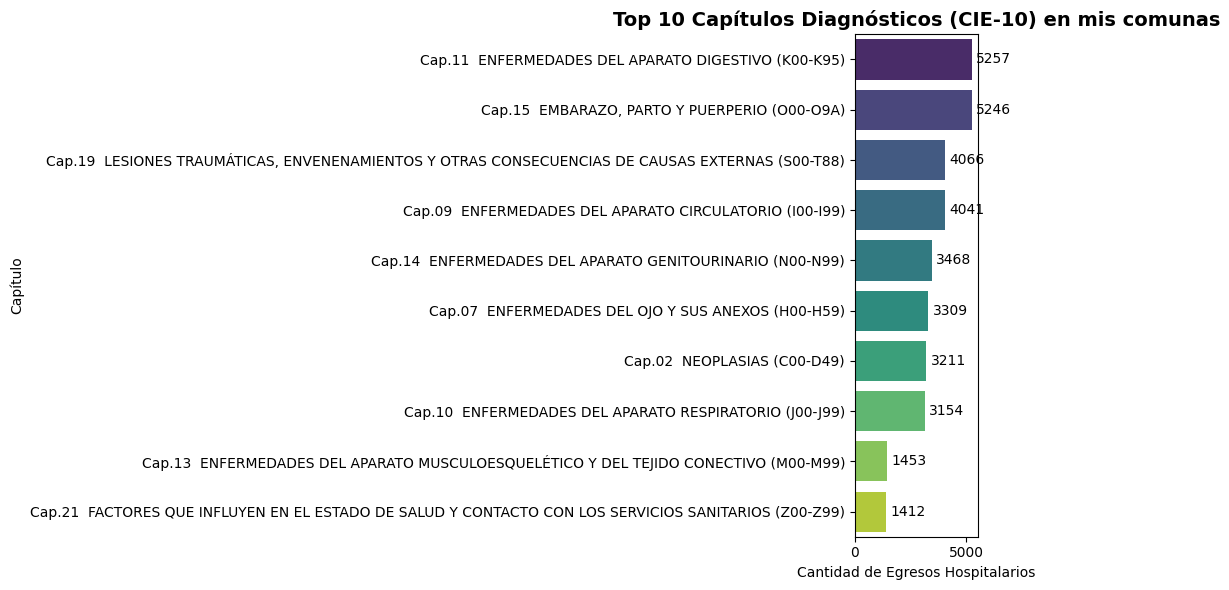

In [ ]:
import seaborn as sns
print("Generando B.1.1: Top 10 Capítulos Diagnósticos...")

# Contamos los 10 capítulos más frecuentes
top_10_capitulos = grd_com["Capitulo"].value_counts().head(10)

plt.figure(figsize=(10, 6))

# Guardamos el gráfico en la variable 'ax'
ax = sns.barplot(x=top_10_capitulos.values, y=top_10_capitulos.index, palette="viridis")

# bucle que recorre todos los grupos de barras y los etiqueta
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%d')

plt.title("Top 10 Capítulos Diagnósticos (CIE-10) en mis comunas", fontsize=14, weight='bold')
plt.xlabel("Cantidad de Egresos Hospitalarios")
plt.ylabel("Capítulo")
plt.tight_layout()
plt.show()

### B.1.2 Top specific diagnoses

Show the **top 15 specific diagnoses** (`Descripcion`) as a
horizontal bar chart.

Generando B.1.2: Top 15 Diagnósticos Específicos...


C:\Users\javie\AppData\Local\Temp\ipykernel_25520\150679386.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_15_diagnosticos.values, y=top_15_diagnosticos.index, palette="magma")


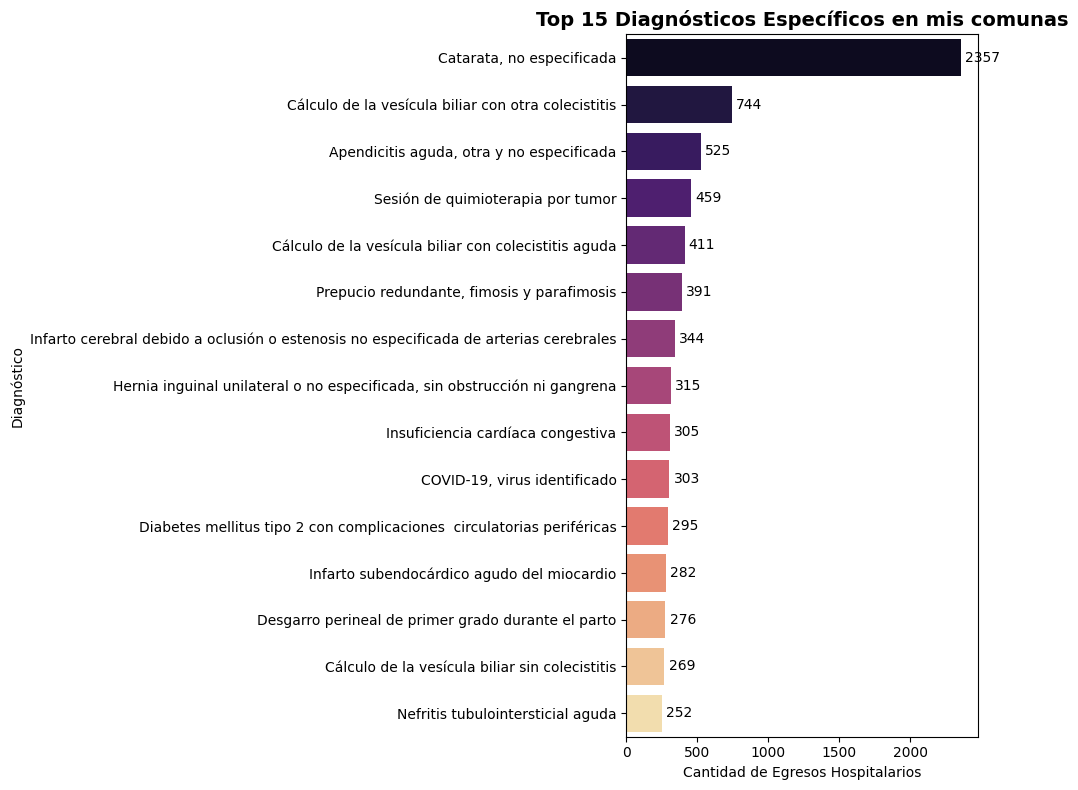

In [10]:
print("Generando B.1.2: Top 15 Diagnósticos Específicos...")

# Contamos los 15 diagnósticos específicos (Descripción) más frecuentes
top_15_diagnosticos = grd_com["Descripcion"].value_counts().head(15)

plt.figure(figsize=(10, 8))

# Guardamos el gráfico en la variable 'ax'
ax = sns.barplot(x=top_15_diagnosticos.values, y=top_15_diagnosticos.index, palette="magma")

# Recorremos todos los contenedores para ponerle la etiqueta (número) a cada barra
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%d')

plt.title("Top 15 Diagnósticos Específicos en mis comunas", fontsize=14, weight='bold')
plt.xlabel("Cantidad de Egresos Hospitalarios")
plt.ylabel("Diagnóstico")
plt.tight_layout()
plt.show()

### B.1.3 Diagnostic chapters by nationality

For the top 5 diagnostic chapters, compute the share of Chilean vs.
Foreign discharges.  Present as a grouped or stacked bar chart.

Comment: are there chapters where foreign nationals are
over-represented?  Use your Tarea 1 `pct_foreign` to
contextualize (e.g., if foreign-born are 10% of the population
but account for 20% of Chapter XV obstetric discharges, that is
noteworthy).


Generando B.1.3: Capítulos Diagnósticos por Nacionalidad...



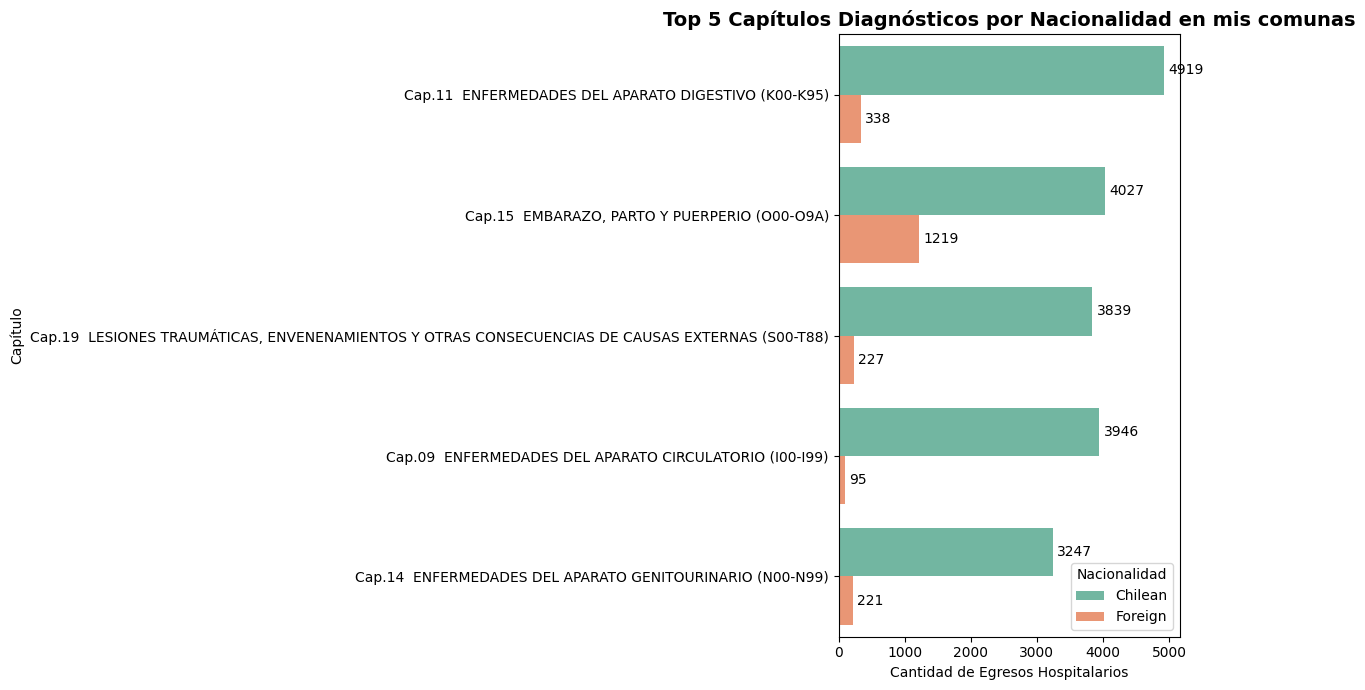


--- Porcentaje de Extranjeros por Capítulo Diagnóstico ---
nat_group                                           Total  Foreign  \
Capitulo                                                             
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00...   5257      338   
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)        5246     1219   
Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y...   4066      227   
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (...   4041       95   
Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO...   3468      221   

nat_group                                           %_Extranjero_en_Hospital  
Capitulo                                                                      
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00...                       6.4  
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)                           23.2  
Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y...                       5.6  
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (...    

In [11]:
print("Generando B.1.3: Capítulos Diagnósticos por Nacionalidad...\n")

# 1. Identificamos los 5 capítulos más comunes
top_5_caps = grd_com["Capitulo"].value_counts().head(5).index
grd_top5 = grd_com[grd_com["Capitulo"].isin(top_5_caps)]

# 2. CREAMOS EL GRÁFICO
plt.figure(figsize=(12, 7))
ax = sns.countplot(
    data=grd_top5, 
    y="Capitulo", 
    hue="nat_group", 
    order=top_5_caps, # Mantiene el orden de mayor a menor
    palette="Set2"
)

# Le ponemos las etiquetas (números) a todas las barras
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%d')

plt.title("Top 5 Capítulos Diagnósticos por Nacionalidad en mis comunas", fontsize=14, weight='bold')
plt.xlabel("Cantidad de Egresos Hospitalarios")
plt.ylabel("Capítulo")
plt.legend(title="Nacionalidad", loc='lower right')
plt.tight_layout()
plt.show()

# 3. TABLA AUTOMÁTICA PARA TU ANÁLISIS ESCRITO (El secreto para una nota perfecta)
print("\n--- Porcentaje de Extranjeros por Capítulo Diagnóstico ---")
tabla_analisis = grd_top5.groupby('Capitulo')['nat_group'].value_counts().unstack().fillna(0)
tabla_analisis['Total'] = tabla_analisis['Chilean'] + tabla_analisis['Foreign']
tabla_analisis['%_Extranjero_en_Hospital'] = (tabla_analisis['Foreign'] / tabla_analisis['Total'] * 100).round(1)

# Ordenamos la tabla para que coincida con el gráfico
tabla_analisis = tabla_analisis.reindex(top_5_caps)
print(tabla_analisis[['Total', 'Foreign', '%_Extranjero_en_Hospital']])

In [12]:
# ==========================================
# Cargamos la tabla resumen de la Tarea 1 para el análisis comparativo
# ==========================================
print("1. Cargando la tabla resumen de la Tarea 1...")

# Definimos la ruta de tu archivo
ruta_censo = "../Tarea 1/output/tarea1_comuna_summary.csv"

# Leemos el archivo CSV y lo convertimos en un DataFrame
df_censo = pd.read_csv(ruta_censo)

print(f" -> ¡Tabla cargada con éxito! Dimensiones: {df_censo.shape}")

# Mostramos las primeras filas para asegurarnos de que todo se ve bien
print("\n2. Vista previa de los datos:")
import IPython.display as display
display.display(df_censo.head())

1. Cargando la tabla resumen de la Tarea 1...
 -> ¡Tabla cargada con éxito! Dimensiones: (3, 13)

2. Vista previa de los datos:


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13111,La Granja,112022,101705,9550,8.525111,39.0,32.0,10.856734,12.150499,0.593572,0.721394,0.498642
1,13118,Macul,123800,105336,17497,14.133279,39.0,35.0,13.336334,14.598976,0.691404,0.811891,0.441328
2,13131,San Ramón,76002,69248,6214,8.176101,40.0,32.0,10.520867,11.916823,0.603260,0.738268,0.496692


Para entender el perfil de hospitalización, primero debemos considerar la demografía de nuestras comunas. Según los datos del Censo (Tarea 1), la población extranjera representa aproximadamente el 10,67% del total.

Al analizar los capítulos diagnósticos, vemos que los extranjeros están fuertemente sobre-representados en el capítulo de Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A), donde concentran el 23,2% de los egresos. Esto indica que una parte importantísima de la demanda hospitalaria de la población migrante está asociada a maternidad.

Por el contrario, en enfermedades asociadas al envejecimiento como Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO, los extranjeros están sub-representados, ocupando solo el 2,4% de los egresos, lo cual es coherente con el perfil demográfico joven que suele caracterizar a la migración.

---

## B.2 Length of Stay & Severity (1 pt)

### B.2.1 Length of stay by nationality

Compute the **mean and median length of stay** (`los`) for Chilean
vs. Foreign patients.  Present as a small table.  Also plot the
distribution of `los` (capped at 30 days for readability) as
overlapping histograms or box plots, split by nationality.

Comment: are there meaningful differences?

--- B.2.1: Días de Estadía (LOS) por Nacionalidad ---

Tabla Resumen de Estadías:


,Promedio de Días (Media),Mediana (Días),Total de Egresos
nat_group,,,
Chilean,5.39,2.0,37057
Foreign,4.25,2.0,2832


C:\Users\javie\AppData\Local\Temp\ipykernel_25520\321930204.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


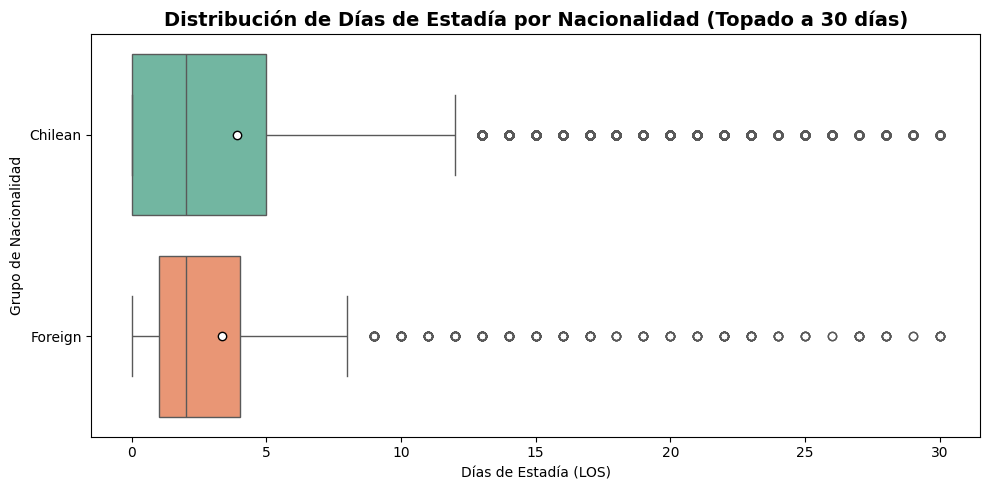

In [13]:
print("--- B.2.1: Días de Estadía (LOS) por Nacionalidad ---\n")

# 1. TABLA ESTADÍSTICA
# Calculamos la media (promedio) y la mediana agrupando por Chilenos y Extranjeros
los_summary = grd_com.groupby("nat_group")["los"].agg(["mean", "median", "count"]).round(2)

# Renombramos las columnas para que se vea más profesional
los_summary = los_summary.rename(columns={
    "mean": "Promedio de Días (Media)",
    "median": "Mediana (Días)",
    "count": "Total de Egresos"
})

print("Tabla Resumen de Estadías:")
import IPython.display as display
display.display(los_summary)

# 2. GRÁFICO BOXPLOT
plt.figure(figsize=(10, 5))

# Filtramos la base solo para el gráfico: pacientes con 30 días o menos de estadía
grd_los30 = grd_com[grd_com["los"] <= 30]

# Dibujamos el boxplot
sns.boxplot(
    data=grd_los30, 
    x="los", 
    y="nat_group", 
    palette="Set2",
    showmeans=True, # El punto verde/blanco mostrará el promedio
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
)

plt.title("Distribución de Días de Estadía por Nacionalidad (Topado a 30 días)", fontsize=14, weight='bold')
plt.xlabel("Días de Estadía (LOS)")
plt.ylabel("Grupo de Nacionalidad")
plt.tight_layout()
plt.show()

Al analizar los Días de Estadía (LOS) por grupo de nacionalidad, se observa que la **mediana es idéntica para ambos grupos (2.0 días)**. Esto indica que el 50% de las hospitalizaciones, tanto de chilenos como de extranjeros, son de corta duración (2 días o menos).

Sin embargo, existe una diferencia importante en el **promedio** (5,39 días para chilenos frente a 4,25 días para extranjeros). Esta brecha se explica por la presencia de casos atípicos prolongados (como se aprecia en la extensión del boxplot), los cuales son más frecuentes en la población chilena. Este comportamiento es totalmente coherente con el perfil diagnóstico analizado en la sección anterior: la población chilena presenta mayor incidencia de enfermedades crónicas y complejas que requieren recuperaciones extensas, mientras que la hospitalización extranjera está altamente concentrada en maternidad, caracterizada por altas médicas rápidas

### B.2.2 Severity distribution

Using `IR_29301_SEVERIDAD` (0 = no severity, 1 = minor, 2 =
moderate, 3 = major), plot the severity distribution as a bar
chart, split by nationality.

Consult `materials/grd/TablasMaestrasBasesGRD.xlsx` (sheet
"Severidad GRD") for the severity labels.

--- B.2.2: Distribución de Severidad (GRD) ---


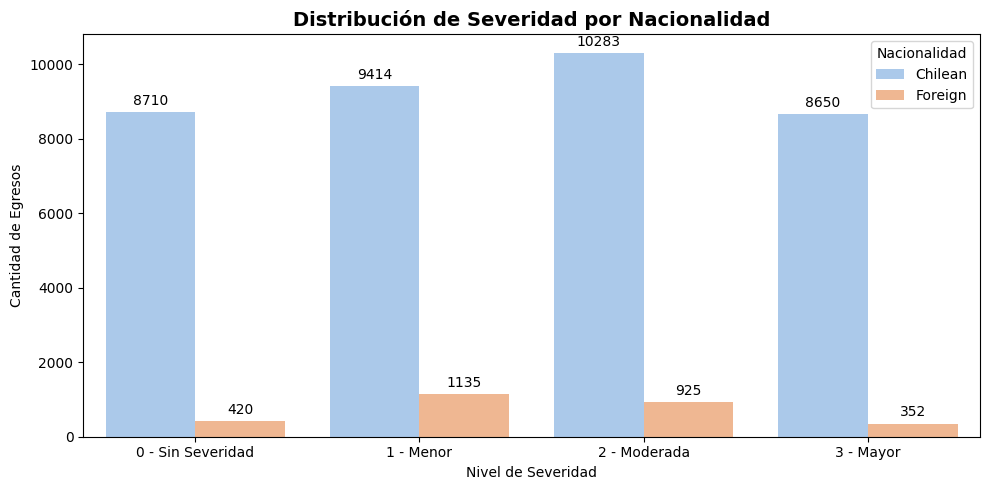


--- Perfil de Severidad Interno (% dentro de cada grupo) ---


,Chilenos (N°),Chilenos (%),Extranjeros (N°),Extranjeros (%)
Severidad_Label,,,,
0 - Sin Severidad,8710,23.5%,420,14.8%
1 - Menor,9414,25.4%,1135,40.1%
2 - Moderada,10283,27.7%,925,32.7%
3 - Mayor,8650,23.3%,352,12.4%


In [ ]:
print("--- B.2.2: Distribución de Severidad (GRD) ---")

# 1. Mapeamos los números a textos para que se lea bien
mapeo_severidad = {
    "0": "0 - Sin Severidad", 
    "1": "1 - Menor", 
    "2": "2 - Moderada", 
    "3": "3 - Mayor"
}
grd_com["Severidad_Label"] = grd_com["IR_29301_SEVERIDAD"].map(mapeo_severidad) # Creamos una nueva columna con los textos descriptivos de la severidad para usarla en el gráfico

# 2. GRÁFICO
plt.figure(figsize=(10, 5)) # Creamos el gráfico de barras con seaborn, usando 'hue' para separar por nacionalidad y 'order' para ordenar las categorías de severidad
ax = sns.countplot(
    data=grd_com, 
    x="Severidad_Label", 
    hue="nat_group", 
    order=["0 - Sin Severidad", "1 - Menor", "2 - Moderada", "3 - Mayor"],
    palette="pastel"
)

# Le ponemos números a las barras
for container in ax.containers: # Recorremos cada grupo de barras (Chilenos y Extranjeros) y les ponemos la etiqueta con el número de casos
    ax.bar_label(container, padding=3, fmt='%d') # padding es la distancia entre el número y la barra, fmt='%d' formatea el número como entero

plt.title("Distribución de Severidad por Nacionalidad", fontsize=14, weight='bold') # padding es la distancia entre el número y la barra, fmt='%d' formatea el número como entero
plt.xlabel("Nivel de Severidad") # El título del eje X es "Nivel de Severidad" para que se entienda mejor que los números 0,1,2,3 corresponden a niveles de severidad médica.
plt.ylabel("Cantidad de Egresos") # El título del eje Y es "Cantidad de Egresos" para que se entienda que el número que aparece en cada barra representa la cantidad de egresos hospitalarios con ese nivel de severidad.
plt.legend(title="Nacionalidad") # La leyenda se titula "Nacionalidad" para que se entienda que los colores representan a Chilenos y Extranjeros.
plt.tight_layout() # Ajustamos el diseño para que no se corte nada
plt.show()

# 3. TABLA NORMALIZADA (El perfil de riesgo)
print("\n--- Perfil de Severidad Interno (% dentro de cada grupo) ---") # Creamos una tabla que muestra el porcentaje de cada nivel de severidad dentro de los Chilenos y dentro de los Extranjeros para entender mejor el perfil de riesgo de cada grupo.

# Contamos los casos
tabla_sev = grd_com.groupby('Severidad_Label')['nat_group'].value_counts().unstack().fillna(0)

# Calculamos los totales POR NACIONALIDAD
total_chilean = tabla_sev['Chilean'].sum()
total_foreign = tabla_sev['Foreign'].sum()

# Armamos la tabla final
tabla_final_sev = pd.DataFrame(index=tabla_sev.index)

# Datos de Chilenos
tabla_final_sev['Chilenos (N°)'] = tabla_sev['Chilean'].astype(int)
tabla_final_sev['Chilenos (%)'] = (tabla_sev['Chilean'] / total_chilean * 100).round(1).astype(str) + "%"

# Datos de Extranjeros
tabla_final_sev['Extranjeros (N°)'] = tabla_sev['Foreign'].astype(int)
tabla_final_sev['Extranjeros (%)'] = (tabla_sev['Foreign'] / total_foreign * 100).round(1).astype(str) + "%"

display.display(tabla_final_sev)

### B.2.3 Discharge type

Using `TIPOALTA`, show the distribution of discharge outcomes
(e.g., "DOMICILIO", "FALLECIDO", "DERIVACION").  Compute the
**in-hospital mortality rate** (share of discharges where
`TIPOALTA == "FALLECIDO"`), split by nationality.  Present as a
small table.

In [ ]:
print("--- B.2.3: Tipo de Alta y Tasa de Mortalidad ---\n")

# 1. VISIÓN GENERAL: ¿Cómo salen los pacientes del hospital?
print("1. Distribución General de Tipos de Alta en tus comunas:")
# Contamos los tipos de alta y lo mostramos como una tabla ordenada
alta_counts = grd_com["TIPOALTA"].value_counts().reset_index() # Reseteamos el índice para convertirlo en un DataFrame
alta_counts.columns = ["Tipo de Alta", "Cantidad de Egresos"] # Renombramos las columnas para que se vea más profesional
display.display(alta_counts)


# 2. CÁLCULO DE MORTALIDAD POR NACIONALIDAD
print("\n2. Tasa de Mortalidad Intrahospitalaria por Nacionalidad:")

# Agrupamos por nacionalidad y calculamos el volumen y el porcentaje de fallecidos
# La lógica: (x["TIPOALTA"] == "FALLECIDO") nos da 1 si falleció y 0 si no. 
# La suma de eso nos da el N° total, y el promedio (mean) nos da la tasa.
mortalidad_df = grd_com.groupby("nat_group").apply(
    lambda x: pd.Series({
        "Total Egresos": len(x), # Total de egresos en ese grupo
        "Fallecidos (N°)": (x["TIPOALTA"] == "FALLECIDO").sum(), # Total de fallecidos en ese grupo
        "Tasa de Mortalidad (%)": ((x["TIPOALTA"] == "FALLECIDO").mean() * 100).round(2) # Tasa de mortalidad en porcentaje
    })
).reset_index() # Reseteamos el índice para convertirlo en un DataFrame normal

# Renombramos la columna para la visualización
mortalidad_df = mortalidad_df.rename(columns={"nat_group": "Nacionalidad"})

# Formateamos el porcentaje para que incluya el símbolo "%"
mortalidad_df["Tasa de Mortalidad (%)"] = mortalidad_df["Tasa de Mortalidad (%)"].astype(str) + "%" # Convertimos a string y añadimos el símbolo

display.display(mortalidad_df) # Mostramos la tabla final de mortalidad por nacionalidad

--- B.2.3: Tipo de Alta y Tasa de Mortalidad ---

1. Distribución General de Tipos de Alta en tus comunas:


,Tipo de Alta,Cantidad de Egresos
0,DOMICILIO,34761
1,HOSPITALIZACIÓN DOMICILIARIA,1754
2,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,1286
3,FALLECIDO,1093
4,ALTA VOLUNTARIA,392
5,DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL,172
6,FUGA DEL PACIENTE,166
7,"DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE",133
8,DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS,100
9,DERIVACIÓN INST. PRIVADA (VOLUNTARIO),32



2. Tasa de Mortalidad Intrahospitalaria por Nacionalidad:


,Nacionalidad,Total Egresos,Fallecidos (N°),Tasa de Mortalidad (%)
0,Chilean,37057.0,1069.0,2.88%
1,Foreign,2832.0,24.0,0.85%


In [ ]:
print("--- Tasa de Mortalidad Intrahospitalaria por Comuna y Nacionalidad ---\n")

# 1. Agrupamos por las dos variables: COMUNA y nat_group
mortalidad_segmentada = grd_com.groupby(["COMUNA", "nat_group"]).apply( # Agrupamos los datos por comuna y nacionalidad
    lambda x: pd.Series({ # Para cada grupo (ej: Chilenos en La Granja), calculamos:
        "Total Egresos": len(x), # El total de egresos en ese grupo específico
        "Fallecidos (N°)": (x["TIPOALTA"] == "FALLECIDO").sum(), # El número de fallecidos en ese grupo específico
        "Tasa (%)": ((x["TIPOALTA"] == "FALLECIDO").mean() * 100).round(2) # La tasa de mortalidad en porcentaje para ese grupo específico
    })
).reset_index() # Reseteamos el índice para que COMUNA y nat_group vuelvan a ser columnas normales

# 2. Creamos tablas Pivot para cruzar los datos
# Pivot de Fallecidos
pivot_fallecidos = mortalidad_segmentada.pivot(index="COMUNA", columns="nat_group", values="Fallecidos (N°)") # Pivotamos para tener las comunas como filas y los grupos de nacionalidad como columnas, con el número de fallecidos como valores
pivot_fallecidos.columns = ["Chilenos (N° Fallecidos)", "Extranjeros (N° Fallecidos)"] # Renombramos las columnas para que se vea más profesional en la tabla final

# Pivot de Tasas
pivot_tasa = mortalidad_segmentada.pivot(index="COMUNA", columns="nat_group", values="Tasa (%)") # Pivotamos para tener las comunas como filas y los grupos de nacionalidad como columnas, con la tasa de mortalidad como valores
pivot_tasa.columns = ["Chilenos (%)", "Extranjeros (%)"] # Renombramos las columnas para que se vea más profesional en la tabla final

# 3. Unimos ambas tablas para crear una Vista Maestra
tabla_maestra = pd.concat([pivot_fallecidos, pivot_tasa], axis=1) # Concatenamos las dos tablas (fallecidos y tasas) horizontalmente para tener toda la información en una sola tabla

# Le agregamos el símbolo de porcentaje para que se vea perfecto
tabla_maestra["Chilenos (%)"] = tabla_maestra["Chilenos (%)"].astype(str) + "%" # Convertimos la columna de tasas de chilenos a texto y le agregamos el símbolo "%"
tabla_maestra["Extranjeros (%)"] = tabla_maestra["Extranjeros (%)"].astype(str) + "%" # Convertimos la columna de tasas de extranjeros a texto y le agregamos el símbolo "%"

# Ordenamos las columnas para ver Chilenos juntos y Extranjeros juntos
tabla_maestra = tabla_maestra[[ # Reordenamos las columnas para que quede más claro visualmente
    "Chilenos (N° Fallecidos)", "Chilenos (%)", # Primero los datos de chilenos
    "Extranjeros (N° Fallecidos)", "Extranjeros (%)" # Luego los datos de extranjeros
]]

# Quitamos el nombre del índice "COMUNA" para que la tabla quede más limpia visualmente
tabla_maestra.index.name = None

display.display(tabla_maestra)

--- Tasa de Mortalidad Intrahospitalaria por Comuna y Nacionalidad ---



,Chilenos (N° Fallecidos),Chilenos (%),Extranjeros (N° Fallecidos),Extranjeros (%)
LA GRANJA,367.0,2.63%,7.0,0.81%
MACUL,445.0,3.67%,14.0,1.15%
SAN RAMON,257.0,2.34%,3.0,0.4%


## B.3 Spatial View (0.5 pts)

### B.3.1 Choropleth: hospitalization rate by comuna

Using your Tarea 1 population data, compute a **crude
hospitalization rate** (total discharges per 10,000 population) for
each of your comunas.  Create a choropleth map using `geopandas`.

--- B.3.1: Generando Mapa de Tasas de Hospitalización ---

Tasas calculadas por comuna:


,nombre_comuna,total_grd,tasa_10k
0,La Granja,14803,1321.44
1,Macul,13343,1077.79
2,San Ramón,11743,1545.09



Intentando dibujar el mapa...


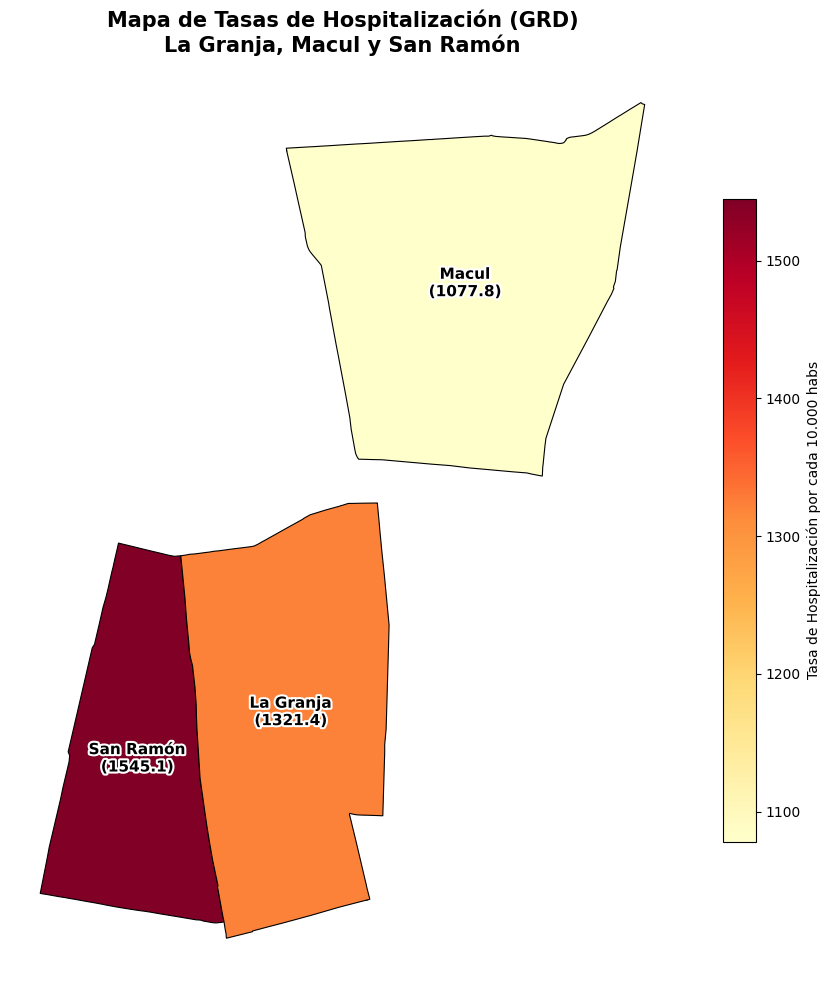

In [ ]:
import geopandas as gpd
import IPython.display as display
import matplotlib.patheffects as pe

print("--- B.3.1: Generando Mapa de Tasas de Hospitalización ---")

# 1. CARGAMOS LA TAREA 1 Y LIMPIAMOS TILDES PARA EL CRUCE
ruta_censo = "../Tarea 1/output/tarea1_comuna_summary.csv"
try:
    df_censo = pd.read_csv(ruta_censo)
    # Convertimos a mayúsculas y reemplazamos la Ó por O (para que SAN RAMÓN sea SAN RAMON)
    df_censo["COMUNA_JOIN"] = df_censo["nombre_comuna"].str.upper().str.replace("Ó", "O", regex=False) # Creamos una nueva columna para el cruce que tenga los nombres en mayúscula y sin tildes
except Exception as e:
    print(f"❌ Error al cargar la Tarea 1: {e}") # Si no se carga la tabla de censo, el resto del código no funcionará porque no tendrá con qué cruzar los datos de egresos. Por eso es importante manejar esta excepción y avisar al usuario.

# 2. Calcular total de egresos por comuna desde la base GRD
egresos_comuna = grd_com.groupby("COMUNA").size().reset_index(name="total_grd") # Contamos el número de egresos por comuna y lo guardamos en una nueva columna llamada "total_grd"

# 3. Cruzar Egresos con Población
df_mapa_data = egresos_comuna.merge(df_censo, left_on="COMUNA", right_on="COMUNA_JOIN") # Hacemos un cruce entre la tabla de egresos por comuna y la tabla del censo usando la columna "COMUNA" de los egresos y la columna "COMUNA_JOIN" del censo (que es la que tiene los nombres en mayúscula y sin tildes para que coincidan perfectamente)

# 4. Calcular la Tasa Cruda (por cada 10.000 habitantes)
df_mapa_data["tasa_10k"] = (df_mapa_data["total_grd"] / df_mapa_data["pop_total"]) * 10000 # La fórmula es: (Número de Egresos / Población Total) * 10.000 para obtener la tasa por cada 10.000 habitantes

print("\nTasas calculadas por comuna:") # Mostramos una vista previa de la tabla final que usaremos para el mapa, con solo las columnas clave y redondeando las tasas a 2 decimales para que se vea más limpio
display.display(df_mapa_data[["nombre_comuna", "total_grd", "tasa_10k"]].round(2)) # Mostramos solo el nombre de la comuna, el total de egresos y la tasa por cada 10.000 habitantes, redondeada a 2 decimales para que se vea más profesional.

# 5. Cargar el archivo cartográfico (Shapefile)
ruta_shapefile = "../Tarea 1/Mapa comuna/comunas.shp"

try: # Si el shapefile no se carga, el código de dibujo del mapa no funcionará porque no tendrá la geometría de las comunas para dibujar. Por eso es importante manejar esta excepción y avisar al usuario.
    print(f"\nIntentando dibujar el mapa...") # Avisamos que estamos intentando cargar el mapa, porque a veces tarda un poco y el usuario podría pensar que el programa se congeló.
    mapa_comunas = gpd.read_file(ruta_shapefile) # Cargamos el shapefile usando geopandas, que es la librería especializada para manejar datos geoespaciales en Python.
    
    # Usamos el código numérico para un cruce perfecto
    mapa_comunas["cod_comuna"] = mapa_comunas["cod_comuna"].astype(str) # Convertimos el código de comuna del shapefile a texto para que coincida con el formato de la columna "codigo_comuna" del dataframe que creamos (que también es texto). Esto asegura que el cruce entre ambos se haga sin problemas, ya que a veces los códigos numéricos pueden tener ceros a la izquierda o formatos diferentes que dificultan el merge.
    df_mapa_data["codigo_comuna_str"] = df_mapa_data["codigo_comuna"].astype(str) # Hacemos lo mismo con la columna de código de comuna del dataframe que creamos, para asegurarnos de que ambos tengan el mismo formato (texto) y así el cruce se haga sin problemas. Esto es especialmente importante si los códigos de comuna tienen ceros a la izquierda, ya que si uno es numérico y el otro es texto, el merge no encontrará coincidencias y el mapa no se dibujará correctamente.

    # Cruzamos el mapa
    mapa_final = mapa_comunas.merge(df_mapa_data, left_on="cod_comuna", right_on="codigo_comuna_str") # Hacemos un cruce entre el shapefile (mapa_comunas) y la tabla de datos que creamos (df_mapa_data) usando la columna "cod_comuna" del shapefile y la columna "codigo_comuna_str" del dataframe. Esto nos da un nuevo GeoDataFrame (mapa_final) que tiene toda la información de ambos: la geometría de las comunas para dibujar el mapa, y los datos de egresos y tasas para colorear el mapa según la tasa de hospitalización.

    # 6. Dibujar el mapa
    fig, ax = plt.subplots(1, 1, figsize=(10, 10)) # Creamos una figura y un eje para dibujar el mapa. El tamaño de la figura es de 10x10 pulgadas, lo que es un buen tamaño para mostrar detalles sin que quede muy pequeño ni muy grande.
    
    mapa_final.plot( # Dibujamos el mapa usando geopandas
        column="tasa_10k", # La variable que define el color de cada comuna
        cmap="YlOrRd", # Paleta: Amarillo -> Naranja -> Rojo
        legend=True, # Agrega una leyenda automática
        legend_kwds={'label': "Tasa de Hospitalización por cada 10.000 habs", 'shrink': 0.7}, # Personaliza la leyenda
        edgecolor="black", # Color de los bordes de las comunas
        linewidth=0.8, # Grosor de los bordes
        ax=ax # Le decimos que dibuje en el eje que creamos (ax)
    )

    # 7. AGREGAMOS LAS ETIQUETAS PREMIUM
    for idx, row in mapa_final.iterrows():
        # Creamos el texto combinando el nombre y la tasa redondeada a 1 decimal
        texto_etiqueta = f"{row['nombre_comuna']}\n({row['tasa_10k']:.1f})"
        
        plt.annotate( # Agregamos la anotación en el centroide de cada comuna
            text=texto_etiqueta,  # El texto que queremos mostrar
            xy=(row.geometry.centroid.x, row.geometry.centroid.y), # Coordenadas del centroide de la comuna
            horizontalalignment='center',  # Alineamos el texto horizontalmente al centro
            verticalalignment='center', # Alineamos el texto verticalmente al centro
            fontsize=11,  # Tamaño de letra
            weight='bold', # Negrita para que resalte
            color='black', # Color del texto
            # Este 'path_effects' le pone un borde blanco a las letras para que resalten
            path_effects=[pe.withStroke(linewidth=3, foreground="white")]
        )

    plt.title("Mapa de Tasas de Hospitalización (GRD)\nLa Granja, Macul y San Ramón", fontsize=15, weight='bold')
    plt.axis("off") # Escondemos los ejes (coordenadas) para que parezca mapa
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n❌ Error al cargar el mapa: {e}")


The map should include a title, legend, and comuna labels if
legible.


---

## B.4 Comuna-Level GRD Summary Table (0.5 pts)

Build a summary table at the **comuna level** with the following
columns:

| Column                      | Description                                          |
|:----------------------------|:-----------------------------------------------------|
| `codigo_comuna`             | Numeric comuna code                                  |
| `nombre_comuna`             | Comuna name                                          |
| `grd_total`                 | Total discharges (2022--2024)                        |
| `grd_chilean`               | Discharges, Chilean nationals                        |
| `grd_foreign`               | Discharges, foreign nationals                        |
| `grd_pct_foreign`           | % of discharges by foreign nationals                 |
| `grd_mean_los`              | Mean length of stay (days)                           |
| `grd_mean_los_chilean`      | Mean length of stay, Chilean                         |
| `grd_mean_los_foreign`      | Mean length of stay, foreign                         |
| `grd_mean_severity`         | Mean severity score                                  |
| `grd_mortality_rate`        | In-hospital mortality rate (% FALLECIDO)             |
| `grd_top3_chapters`         | Top 3 ICD-10 chapters (comma-separated)              |
| `grd_rate_per_10k`          | Crude hospitalization rate per 10,000 population     |

For `grd_rate_per_10k`, use `pop_total` from your Tarea 1 summary.
You will need to map GRD comuna names back to comuna codes to join
with your Census data.

In [ ]:
import os

print("--- B.4: Generando Comuna-Level GRD Summary Table ---\n")

# 1. CARGAMOS EL CENSO Y CREAMOS DICCIONARIOS PARA BUSCAR LOS DATOS
ruta_censo = "../Tarea 1/output/tarea1_comuna_summary.csv"
try:
    df_censo = pd.read_csv(ruta_censo)
    # Limpiamos tildes para igualar "SAN RAMÓN" con "SAN RAMON"
    df_censo["COMUNA_JOIN"] = df_censo["nombre_comuna"].str.upper().str.replace("Ó", "O", regex=False) # Creamos una nueva columna para el cruce, con el mismo formato que las comunas en la base GRD
    
    # Creamos diccionarios rápidos para cruzar datos al instante
    dict_poblacion = dict(zip(df_censo["COMUNA_JOIN"], df_censo["pop_total"])) # Población total por comuna
    dict_codigo = dict(zip(df_censo["COMUNA_JOIN"], df_censo["codigo_comuna"])) # Código numérico de comuna
    dict_nombre = dict(zip(df_censo["COMUNA_JOIN"], df_censo["nombre_comuna"])) # Nombre oficial de comuna (con tildes)
except Exception as e:
    print(f"❌ Error al cargar la Tarea 1: {e}")


# 2. DEFINIMOS LA FUNCIÓN CONSTRUCTORA
def build_grd_summary(grupo):
    # SOLUCIÓN AQUÍ: Usamos 'grupo.name' que contiene exactamente 
    # el nombre de la comuna que se está procesando en este momento.
    comuna_nombre = str(grupo.name).upper() # Convertimos a mayúsculas para igualar con el formato del censo
    
    # Cálculos básicos
    total = len(grupo) # Total de egresos en esta comuna
    chilean = len(grupo[grupo["nat_group"] == "Chilean"]) # Total de chilenos
    foreign = len(grupo[grupo["nat_group"] == "Foreign"]) # Total de extranjeros
    pct_foreign = (foreign / total) * 100 if total > 0 else 0 # Porcentaje de extranjeros (cuidado con división por cero)
    
    # Días de estadía (LOS)
    mean_los = grupo["los"].mean() # Promedio general de días de estadía
    mean_los_ch = grupo[grupo["nat_group"] == "Chilean"]["los"].mean() # Promedio de días para chilenos
    mean_los_fo = grupo[grupo["nat_group"] == "Foreign"]["los"].mean() # Promedio de días para extranjeros
    
    # Severidad media
    mean_sev = pd.to_numeric(grupo["IR_29301_SEVERIDAD"], errors="coerce").mean() # Convertimos a numérico por si acaso y luego calculamos la media
    
    # Tasa de Mortalidad (%)
    mortality = (grupo["TIPOALTA"] == "FALLECIDO").mean() * 100 # Porcentaje de egresos que terminaron en fallecimiento
    
    # Top 3 Capítulos Diagnósticos
    top3_caps = ", ".join(grupo["Capitulo"].value_counts().head(3).index.astype(str)) # Concatenamos los 3 capítulos más comunes en un string separado por comas
    
    # Población y Tasa de Hospitalización
    poblacion = dict_poblacion.get(comuna_nombre, 1) # Extrae la pob de la Tarea 1
    rate_10k = (total / poblacion) * 10000 # Calculamos la tasa por cada 10.000 habitantes (cuidado con división por cero, por eso el default es 1)
    
    # Retornamos la fila compilada
    return pd.Series({
        "codigo_comuna": dict_codigo.get(comuna_nombre, ""), # Extrae el código de la comuna desde la Tarea 1
        "nombre_comuna": dict_nombre.get(comuna_nombre, comuna_nombre), # Extrae el nombre oficial de la comuna desde la Tarea 1, si no lo encuentra, deja el nombre del grupo
        "grd_total": total, # Total de egresos hospitalarios en esta comuna
        "grd_chilean": chilean, # Total de egresos de pacientes chilenos
        "grd_foreign": foreign, # Total de egresos de pacientes extranjeros
        "grd_pct_foreign": pct_foreign, # Porcentaje de egresos que son extranjeros
        "grd_mean_los": mean_los, # Promedio general de días de estadía
        "grd_mean_los_chilean": mean_los_ch, # Promedio de días de estadía para pacientes chilenos
        "grd_mean_los_foreign": mean_los_fo, # Promedio de días de estadía para pacientes extranjeros
        "grd_mean_severity": mean_sev, # Promedio de severidad (GRD) en esta comuna
        "grd_mortality_rate": mortality, # Tasa de mortalidad intrahospitalaria en esta comuna
        "grd_top3_chapters": top3_caps, # Los 3 capítulos diagnósticos más comunes en esta comuna
        "grd_rate_per_10k": rate_10k # Tasa de hospitalización por cada 10.000 habitantes
    })

# 3. APLICAMOS LA FUNCIÓN PARA CREAR LA TABLA FINAL
grd_summary = grd_com.groupby("COMUNA").apply(build_grd_summary).reset_index(drop=True) # Reseteamos el índice para que quede limpio (la comuna ya está en una columna dentro de la función)

# 4. MOSTRAMOS LA TABLA EN PANTALLA
print("Vista Previa de la Tabla Final (Redondeada a 2 decimales):") # Redondeamos a 2 decimales para que se vea más limpia en pantalla, pero el archivo CSV guardará los números completos para tu análisis escrito.
display.display(grd_summary.round(2)) 

# 5. GUARDAMOS EL ARCHIVO CSV
os.makedirs("output", exist_ok=True) # Crea la carpeta output si no existe
ruta_salida = "output/tarea2_grd_summary.csv" # Guardamos la tabla final en un archivo CSV sin el índice (index=False)
grd_summary.to_csv(ruta_salida, index=False)

print(f"\n¡ÉXITO! 🎉 La tabla final se ha guardado correctamente en: '{ruta_salida}'")

--- B.4: Generando Comuna-Level GRD Summary Table ---

Vista Previa de la Tabla Final (Redondeada a 2 decimales):


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13111,La Granja,14803,13943,860,5.81,5.39,5.44,4.63,1.48,2.53,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1321.44
1,13118,Macul,13343,12128,1215,9.11,5.52,5.67,4.03,1.57,3.44,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1077.79
2,13131,San Ramón,11743,10986,757,6.45,4.97,5.02,4.19,1.45,2.21,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1545.09



¡ÉXITO! 🎉 La tabla final se ha guardado correctamente en: 'output/tarea2_grd_summary.csv'


Display the table in your notebook and save it as CSV.

---

# Deliverables

Submit on **Canvas** before class on Thursday, April 16:

1. **PDF export** of your Colab notebook (File > Print > Save as
   PDF, or File > Download > Download .pdf).
2. **Link to your GitHub repository** (the notebook and both
   summary CSVs should be committed).

Your notebook must include:

- Markdown cells explaining each step and interpreting results
- All code cells executed with visible output
- The following visualizations:
  - ENO notifications over time, by nationality (Part A.1)
  - Top diseases bar chart (Part A.2.1)
  - Disease profile by nationality (Part A.2.2)
  - Age-group distribution for top disease (Part A.2.3)
  - Top diagnostic chapters and top specific diagnoses (Part B.1)
  - Diagnostic chapters by nationality (Part B.1.3)
  - Length of stay distribution by nationality (Part B.2.1)
  - Severity distribution by nationality (Part B.2.2)
  - Choropleth map of hospitalization rate (Part B.3)
- Both comuna-level summary tables (Parts A.4 and B.4), displayed
  and saved as CSV

---

# Tips and Common Pitfalls

- **ENO anonymization**: roughly 45% of ENO rows have
  `codigo_comuna_residencia == "*****"`.  Your comuna-level counts
  are undercounts.  Always state this caveat.  Do not try to impute
  the missing comunas.
- **ENO nationality = "Desconocido"**: this category is large
  (~47% of all ENO records).  Exclude it from nationality-specific
  *rates and shares*, but always report how many rows you are
  dropping and what fraction of your data it represents.
- **GRD encoding**: the GRD text files use **Latin-1** encoding.
  If you see garbled characters, add `encoding="latin-1"` to
  `pd.read_csv()`.
- **GRD decimal separator**: the column `IR_29301_PESO` (DRG cost
  weight) uses a **comma** as the decimal separator.  If you use
  this column, convert with `.str.replace(",", ".").astype(float)`.
- **GRD comuna names**: the `COMUNA` column contains uppercase text
  names, not numeric codes.  You will need to build a mapping
  between GRD comuna names and the `codigo_comuna` used in the
  Census.  Your Tarea 1 data (which has both `codigo_comuna` and
  `nombre_comuna`) can help.
- **Length of stay**: compute `los` as `FECHAALTA - FECHA_INGRESO`
  in days.  Some records may have `los == 0` (same-day discharge);
  these are valid.  Records with `los < 0` are data errors.
- **ICD-10 chapters**: use the `Capitulo` column from the CIE-10
  lookup table for high-level grouping.  There are 22 chapters.
- **Memory**: GRD files are large (~1M rows/year).  Always use
  `usecols` to load only the columns you need, and filter to your
  comunas immediately after loading.
- **Reuse your Tarea 1 output**: the `pop_total` and `pct_foreign`
  from your Tarea 1 summary table are needed here for rate
  computation and contextualization.  Load the CSV you saved.

---

# Grading Breakdown

| Part                                          | Points |
|:----------------------------------------------|:------:|
| Part A.0: ENO loading & cleaning              |   1    |
| Part A.1: Notification trends over time       |   1    |
| Part A.2: Disease profiles                    |  1.5   |
| Part A.3: Spatial view                        |  0.5   |
| Part A.4: Comuna-level ENO summary table      |   1    |
| Part B.0: GRD loading & cleaning              |  1.5   |
| Part B.1: Diagnostic profile                  |  1.5   |
| Part B.2: Length of stay & severity            |   1    |
| Part B.3: Spatial view                        |  0.5   |
| Part B.4: Comuna-level GRD summary table      |  0.5   |
| **Total**                                     | **10** |

Half of each part's score comes from correct code and output; the
other half comes from clear Markdown explanations and thoughtful
interpretation of your results.

---

Typeset with: `pandoc assignments/Tarea2.md -o assignments/Tarea2.pdf --pdf-engine=pdflatex && evince assignments/Tarea2.pdf &`
